<a href="https://colab.research.google.com/github/celestesmartinez/Trabajo_Final_Analisis_Estadistico_UNAJ_WC/blob/main/trabajo_final_analisis_estadistico_2026_Martinez_Saenz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico Integrador Grupal
## Análisis Estadístico
### Maestría en Ciencia de Datos — UNAJ 2026

**Integrantes:**
- Martinez, Celeste Sabrina
- Saenz, William Darío

**Dataset:** Estación Meteorológica — Mercedes, Corrientes (2023–2024)

**Profesor:** Prof. Marcelo A. Cappelletti

---

**Objetivo:** Integrar y aplicar los conocimientos del curso mediante el análisis estadístico de datos meteorológicos reales.

---

### Estructura del trabajo:

    - Configuración General

    - PARTE I — Estadística Descriptiva

        I-A: Resumen, tipos de datos y detección de GAPS

        I-B: Medidas de posición y dispersión

        I-C: Descripción gráfica y series temporales (por VAs)

        I-D: Verificación de representatividad estacional

    - PARTE II — Regresión Lineal + Test de Hipótesis

        II-A: REGRESIÓN LINEAL SIMPLE Y estimación por MÍNIMOS CUADRADOS (MCO)
        
        II-B: ANÁLISIS DE RESIDUOS y Verificacación de supuestos de las variables aleatorias (VAs)
       
        II-C: EVALUACIÓN DEL MODELO por: Coeficiente de determinación R²  
              Verificación normalidad (por VAs) .
       
        II-D: TEST DE HIPOTESIS: sobre la pendiente β₁:

        II-E: Análisis de sensibilidad (Gap de Otoño)
        
        II-F: REGRESIÓN LINEAL MÚLTIPLE: Análisis de residuos, Intervalos de confianza y predicción.

    - COMPARACIÓN EVALUATIVA DE MODELOS: evaluación modelo: R² y AIC

    - PARTE III — Estadística No Paramétrica
    
        III-A: Test no paramétrico de Spearman


######################################################################
## Configuración General
######################################################################


Se importan las librerías necesarias y se carga el dataset desde el repositorio de GitHub.

In [1]:
import warnings
warnings.filterwarnings("ignore")  # Se suprimen advertencias para mantener la salida limpia

import pandas as pd                          # Librería para manejo de datos en forma de tabla (DataFrame)
import numpy as np                           # Librería para operaciones matemáticas y matriciales
import matplotlib.pyplot as plt              # Librería base para generación de gráficos
import seaborn as sns                        # Librería de visualización de alto nivel, basada en matplotlib
import scipy.stats as stats                  # Módulo estadístico: tests, distribuciones, correlaciones
import statsmodels.api as sm                 # Librería para modelos estadísticos (regresión OLS, QQ-plot, etc.)
from statsmodels.stats.outliers_influence import OLSInfluence  # Para calcular residuos estandarizados del modelo OLS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.api import het_breuschpagan

In [2]:
# *************************************************************
# CARGA DEL DATASET DESDE GITHUB Y VISUALIZACIÓN INICIAL
# *************************************************************

# URL del archivo CSV en el repositorio de Celeste en GitHub
archivo = "https://raw.githubusercontent.com/celestesmartinez/Trabajo_Final_Analisis_Estadistico_UNAJ_WC/main/04_Corrientes_Mercedes.csv"

df = pd.read_csv(archivo, sep=";")          # Se lee el CSV indicando que el separador es punto y coma (;)

df['Fecha'] = pd.to_datetime(df["Fecha"])   # Se convierte la columna Fecha al tipo datetime de pandas
df['Fecha'] = df['Fecha'].dt.date           # Se conserva solo la parte de fecha (se elimina la hora 00:00:00)

display(df.head())                          # Se muestran las primeras 5 filas para verificar la carga correcta
print()

df.describe().round(2)                      # Se muestran estadísticas descriptivas básicas, redondeadas a 2 decimales

,Fecha,Temperatura_Abrigo_150cm,Humedad_Media,Presion_Media,Radiacion_Global
0,2023-01-01,29.80764,59,967.1437,15.40440
1,2023-01-03,25.69097,39,974.9562,27.38832
2,2023-01-10,30.17917,43,984.9236,19.16209
3,2023-01-11,29.66944,56,985.2405,22.01232
4,2023-01-12,25.65000,79,980.1293,13.10226


,Temperatura_Abrigo_150cm,Humedad_Media,Presion_Media,Radiacion_Global
count,554.00,554.00,554.00,554.00
mean,21.11,84.04,1000.20,18.22
std,6.05,13.70,7.64,8.35
min,3.92,38.00,967.14,0.46
25%,16.98,77.00,996.79,12.60
50%,21.61,87.00,1000.60,18.15
75%,25.70,95.00,1004.38,24.57
max,32.90,100.00,1020.97,36.57


---
######################################################################
# PARTE I — Estadística Descriptiva
######################################################################

Se realiza un análisis exploratorio completo del dataset: estructura, tipos de datos, medidas estadísticas y representaciones gráficas.

## I-A — Resumen y tipos de datos

**Objetivo:** conocer cuántos datos hay, qué variables existen y de qué tipo es cada una.

In [3]:
# *************************************************************
# RESUMEN GENERAL DEL DATASET
# *************************************************************

print("=" * 55)
print("         RESUMEN GENERAL DEL DATASET")
print("=" * 55)
print(f"  Número de registros (filas):    {df.shape[0]}")   # .shape[0] devuelve la cantidad de filas
print(f"  Número de variables (columnas): {df.shape[1]}")   # .shape[1] devuelve la cantidad de columnas
print(f"  Período cubierto: {df['Fecha'].min()} → {df['Fecha'].max()}")  # Rango temporal del dataset
print("=" * 55)

         RESUMEN GENERAL DEL DATASET
  Número de registros (filas):    554
  Número de variables (columnas): 5
  Período cubierto: 2023-01-01 → 2024-11-22


In [4]:
# *************************************************************
# DESCRIPCIÓN DE LAS VARIABLES DEL DATASET
# *************************************************************

# Se describe el significado físico y el tipo de cada variable
descripcion = {
    'Fecha':                    'Fecha de medición diaria (tipo: object/date)',
    'Temperatura_Abrigo_150cm': 'Temperatura del aire a 150 cm de altura en °C (tipo: float64)',
    'Humedad_Media':            'Humedad relativa media diaria en % (tipo: int64)',
    'Presion_Media':            'Presión atmosférica media en hPa (tipo: float64)',
    'Radiacion_Global':         'Radiación solar global diaria en MJ/m² (tipo: float64)'
}

print("Descripción de cada variable:\n")
for var, desc in descripcion.items():     # Se itera sobre cada par variable-descripción
    print(f" - {var}: {desc}\n")           # Se imprime con formato de bullet point

print()
print("Valores faltantes por columna:")
print(df.isnull().sum())                  # .isnull() detecta valores NaN; .sum() los cuenta por columna

Descripción de cada variable:

 - Fecha: Fecha de medición diaria (tipo: object/date)

 - Temperatura_Abrigo_150cm: Temperatura del aire a 150 cm de altura en °C (tipo: float64)

 - Humedad_Media: Humedad relativa media diaria en % (tipo: int64)

 - Presion_Media: Presión atmosférica media en hPa (tipo: float64)

 - Radiacion_Global: Radiación solar global diaria en MJ/m² (tipo: float64)


Valores faltantes por columna:
Fecha                       0
Temperatura_Abrigo_150cm    0
Humedad_Media               0
Presion_Media               0
Radiacion_Global            0
dtype: int64


In [5]:
# *************************************************************
# DETECCIÓN DE DISCONTINUIDADES TEMPORALES (GAPS) EN EL DATASET
# Un dataset de serie temporal diaria debería tener mediciones
# consecutivas. Se calcula la diferencia en días entre cada
# fecha y la anterior para detectar períodos sin mediciones.
# *************************************************************

df_ordenado = df.sort_values('Fecha').reset_index(drop=True)   # Aseguramos orden cronológico
df_ordenado['Fecha_dt'] = pd.to_datetime(df_ordenado['Fecha']) # Conversión auxiliar a datetime para restar fechas
df_ordenado['gap_dias'] = df_ordenado['Fecha_dt'].diff().dt.days  # Diferencia en días respecto a la fila anterior

gaps = df_ordenado[df_ordenado['gap_dias'] > 7]            # Se consideran gaps relevantes los mayores a una semana

print("=" * 60)
print("  DISCONTINUIDADES TEMPORALES (gaps > 7 días)")
print("=" * 60)
if len(gaps) > 0:
    for idx, fila in gaps.iterrows():
        fecha_anterior = df_ordenado.loc[idx - 1, 'Fecha_dt']      # Última fecha antes del hueco
        print(f"  Gap detectado: {fecha_anterior.date()}  →  {fila['Fecha_dt'].date()}")
        print(f"  Duración: {int(fila['gap_dias'])} días sin mediciones\n")
else:
    print("  No se detectaron discontinuidades mayores a 7 días.")

print("  NOTA METODOLÓGICA:")
print("  El gap principal (22/03/2023 → 17/06/2023, 87 días) elimina")
print("  casi por completo la fase de enfriamiento del otoño 2023")
print("  (abril-mayo). Esta limitación se cuantifica más adelante y")
print("  se evalúa su impacto sobre el modelo de regresión (Parte II).")


  DISCONTINUIDADES TEMPORALES (gaps > 7 días)
  Gap detectado: 2023-03-22  →  2023-06-17
  Duración: 87 días sin mediciones

  Gap detectado: 2024-01-17  →  2024-01-28
  Duración: 11 días sin mediciones

  NOTA METODOLÓGICA:
  El gap principal (22/03/2023 → 17/06/2023, 87 días) elimina
  casi por completo la fase de enfriamiento del otoño 2023
  (abril-mayo). Esta limitación se cuantifica más adelante y
  se evalúa su impacto sobre el modelo de regresión (Parte II).


### Limitación detectada: cobertura temporal incompleta

El dataset combina mediciones de **2023 y 2024**, pero no cubre los mismos períodos en ambos años. En particular, existe un **gap de 87 días (22 de marzo → 17 de junio de 2023)** que elimina casi por completo la fase de enfriamiento otoñal (abril-mayo) de ese año.

**¿Por qué importa esto?** El dataset "tiene" registros de otoño (marzo-mayo), pero el 80% de ellos provienen de 2024 — el otoño 2023 está representado únicamente por 22 días de inicios de marzo, que climatológicamente todavía corresponden a la **cola del verano**, no a la transición real hacia el invierno. Esto se verifica numéricamente en la sección I-D y se evalúa su impacto sobre el modelo de regresión en la Parte II.

## I-B — Medidas de posición y dispersión

**Objetivo:** cuantificar cómo se distribuyen los datos de cada variable numérica.

In [6]:
# *************************************
# MEDIDAS DE POSICIÓN DE CADA ATRIBUTO
# *************************************

# Se seleccionan automáticamente solo las columnas con datos numéricos
columnas_numericas = df.select_dtypes(include=np.number).columns.tolist()
# select_dtypes filtra columnas por tipo; tolist() convierte el resultado en una lista de Python

print("**********************************")
print("Medidas de Posición por atributo")
print("**********************************\n")

for col in columnas_numericas:             # Con el bucle "for" se recorre cada columna numérica
    print(f"\n*** Atributo: {col} ***\n")

    print(f"Media: {df[col].mean():.2f}")         # Media aritmética: suma / n
    print(f"Mediana: {df[col].median():.2f}")     # Valor central cuando los datos están ordenados
    print(f"Moda: {df[col].mode().iloc[0]:.2f}")  # Valor más frecuente; .iloc[0] toma el primero si hay varios

    Q1 = df[col].quantile(0.25)            # Primer cuartil: 25% de los datos queda por debajo
    Q2 = df[col].quantile(0.50)            # Segundo cuartil: coincide con la mediana
    Q3 = df[col].quantile(0.75)            # Tercer cuartil: 75% de los datos queda por debajo

    print(f"Primer Cuartil  (Q1): {Q1:.2f}")
    print(f"Segundo Cuartil (Q2): {Q2:.2f}")
    print(f"Tercer Cuartil  (Q3): {Q3:.2f}")

**********************************
Medidas de Posición por atributo
**********************************


*** Atributo: Temperatura_Abrigo_150cm ***

Media: 21.11
Mediana: 21.61
Moda: 16.69
Primer Cuartil  (Q1): 16.98
Segundo Cuartil (Q2): 21.61
Tercer Cuartil  (Q3): 25.70

*** Atributo: Humedad_Media ***

Media: 84.04
Mediana: 87.00
Moda: 100.00
Primer Cuartil  (Q1): 77.00
Segundo Cuartil (Q2): 87.00
Tercer Cuartil  (Q3): 95.00

*** Atributo: Presion_Media ***

Media: 1000.20
Mediana: 1000.60
Moda: 992.63
Primer Cuartil  (Q1): 996.79
Segundo Cuartil (Q2): 1000.60
Tercer Cuartil  (Q3): 1004.38

*** Atributo: Radiacion_Global ***

Media: 18.22
Mediana: 18.15
Moda: 0.46
Primer Cuartil  (Q1): 12.60
Segundo Cuartil (Q2): 18.15
Tercer Cuartil  (Q3): 24.57


In [7]:
# ************************************
# MEDIDAS DE DISPERSIÓN DE CADA ATRIBUTO
# ************************************

print("*********************************")
print("Medidas de Dispersión por atributo")
print("*********************************\n")

for col in columnas_numericas:             # Se recorre cada columna numérica
    print(f"\n*** Atributo: {col} ***\n")

    Q1  = df[col].quantile(0.25)           # Primer cuartil (necesario para calcular RIC)
    Q3  = df[col].quantile(0.75)           # Tercer cuartil
    RIC = Q3 - Q1                          # Rango Intercuartílico: mide la dispersión del 50% central

    print(f"Rango: {df[col].max() - df[col].min():.2f}")          # Diferencia entre máximo y mínimo
    print(f"Rango Intercuartílico (RIC): {RIC:.2f}")               # Dispersión del 50% central de los datos
    print(f"Varianza: {df[col].var():.2f}")                        # Promedio de las desviaciones al cuadrado
    print(f"Desviación Estándar: {df[col].std():.2f}")             # Raíz cuadrada de la varianza; misma unidad que la variable
    print(f"Coeficiente de variación: {(df[col].std()/df[col].mean())*100:.2f}%")  # Dispersión relativa en %
    print(f"Curtosis: {df[col].kurt():.3f}")                       # Mide si la distribución es más o menos puntiaguda que la normal:
                                                                   # Rangos Curtosis: -1 a 1 Comportamiento bastante normal o estable; 1 a 3 Hay eventos extremos moderados; > 3 Muchos extremos o eventos raros importantes. Revisar outliers.; < -1 Datos muy repartidos, sin picos fuertes.
    print(f"Asimetría (Skewness): {df[col].skew():.3f}\n")         # Mide si los datos se inclinan hacia la izquierda (<0) o derecha (>0) en la distribución:
                                                                   # Rangos Skewness: ≈ 0 (entre -0.5 y 0.5)Distribución aproximadamente simétrica; 0.5 a 1 (o -0.5 a -1)Asimetría moderada; > 1 (o < -1)Asimetría fuerte/marcada

*********************************
Medidas de Dispersión por atributo
*********************************


*** Atributo: Temperatura_Abrigo_150cm ***

Rango: 28.97
Rango Intercuartílico (RIC): 8.72
Varianza: 36.61
Desviación Estándar: 6.05
Coeficiente de variación: 28.67%
Curtosis: -0.472
Asimetría (Skewness): -0.404


*** Atributo: Humedad_Media ***

Rango: 62.00
Rango Intercuartílico (RIC): 18.00
Varianza: 187.60
Desviación Estándar: 13.70
Coeficiente de variación: 16.30%
Curtosis: 0.474
Asimetría (Skewness): -0.986


*** Atributo: Presion_Media ***

Rango: 53.83
Rango Intercuartílico (RIC): 7.58
Varianza: 58.31
Desviación Estándar: 7.64
Coeficiente de variación: 0.76%
Curtosis: 1.173
Asimetría (Skewness): -0.532


*** Atributo: Radiacion_Global ***

Rango: 36.10
Rango Intercuartílico (RIC): 11.97
Varianza: 69.72
Desviación Estándar: 8.35
Coeficiente de variación: 45.83%
Curtosis: -0.697
Asimetría (Skewness): -0.052



## I-C — Descripción gráfica

**Objetivo:** Realizar una inspección gráfica de los cuatro (04) atributos.

Se generan cuatro tipos de gráficos:
- **Histograma:** muestra cómo se distribuye una variable (frecuencia por intervalos)
- **Boxplot:** muestra la mediana, cuartiles y valores atípicos de una variable
- **QQ-plot:** permite explorar de forma gráfica la distribución de las variables, y verificar si tienen aproximación normal
- **Series temporales:** muestra si existen tendencias y *gaps* en las variables según estacionalidad y año

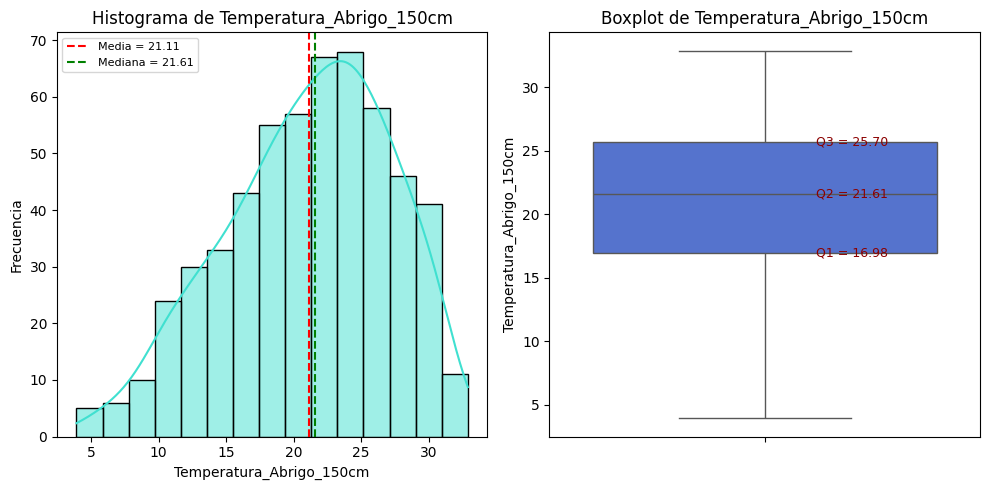

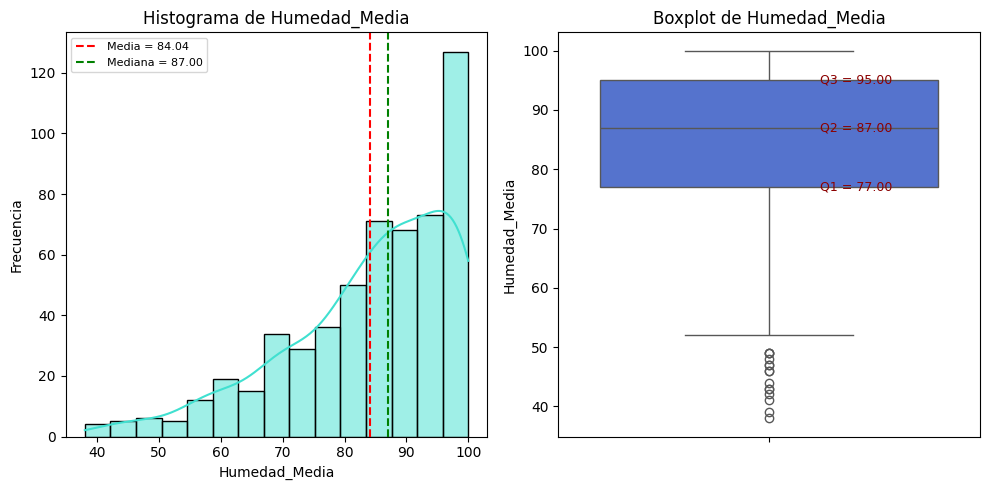

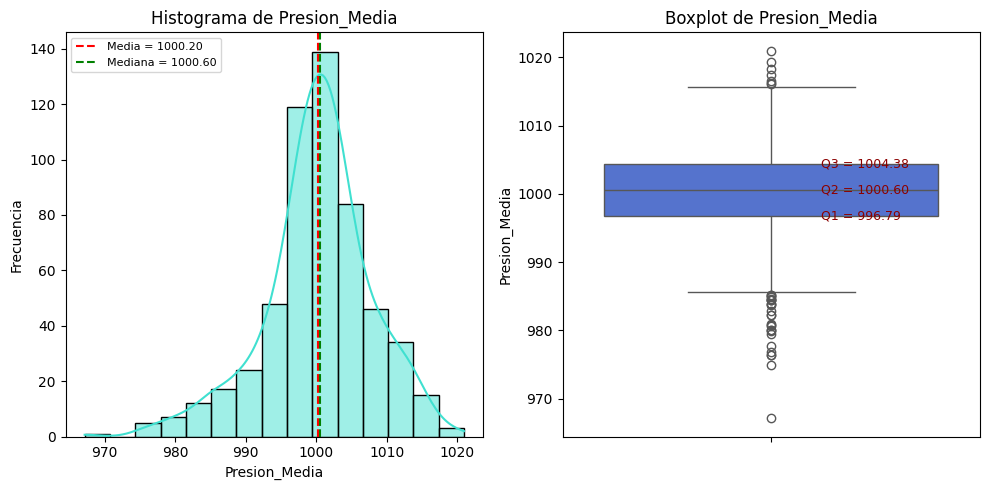

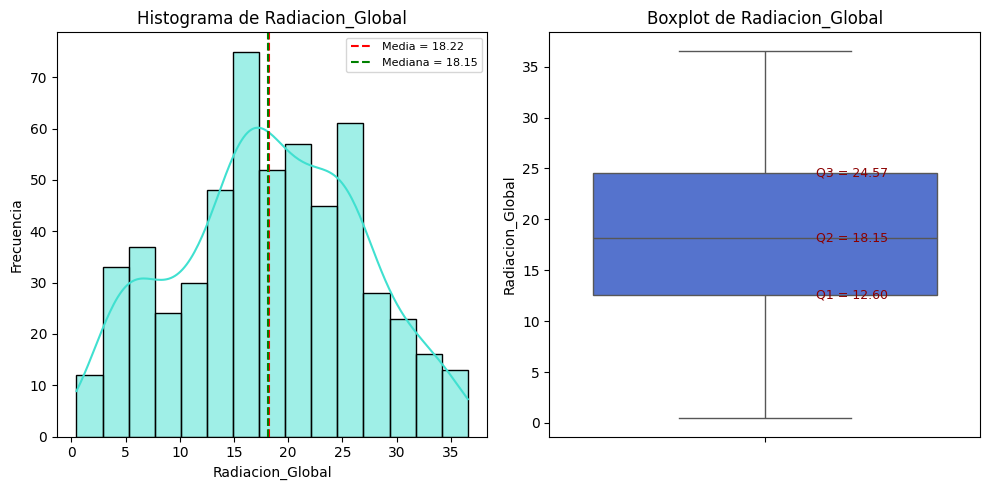

In [8]:
# ************************************
# HISTOGRAMA + BOXPLOT POR VARIABLE
# (análisis de una variable a la vez)
# ************************************

for col in columnas_numericas:             # Se genera un par de gráficos por cada variable numérica: acá se tienen los CUATRO ATRIBUTOS
    plt.figure(figsize=(10, 5))            # Se crea una figura de 10x5 pulgadas (área del gráfico)

    # --- HISTOGRAMA ---
    plt.subplot(1, 2, 1)                   # 1 fila, 2 columnas, 1: primer gráfico (posición izquierda:1): plantilla de disposición de gráficos
    sns.histplot(df[col], kde=True, bins=15, color='turquoise')
    # histplot: dibuja barras de frecuencia
    # kde=True: agrega una curva suavizada de densidad sobre el histograma
    # bins=15: divide los datos en 15 intervalos
    plt.title(f'Histograma de {col}')      # Título del gráfico
    plt.xlabel(col)                        # Etiqueta del eje X
    plt.ylabel('Frecuencia')               # Etiqueta del eje Y

    # --- Etiquetas numéricas de medidas de posición sobre el histograma ---
    media_val   = df[col].mean()           # Media del atributo
    mediana_val = df[col].median()         # Mediana del atributo
    plt.axvline(media_val, color='red', linestyle='--', linewidth=1.5,
                label=f'Media = {media_val:.2f}')      # Línea vertical en la media
    plt.axvline(mediana_val, color='green', linestyle='--', linewidth=1.5,
                label=f'Mediana = {mediana_val:.2f}')  # Línea vertical en la mediana
    plt.legend(fontsize=8)                 # Muestra los valores numéricos en la leyenda

    # --- BOXPLOT ---
    plt.subplot(1, 2, 2)                   # 1 fila, 2 columnas, segundo gráfico (posición derecha:2)
    sns.boxplot(y=df[col], color='royalblue')
    # boxplot: la caja muestra Q1, mediana y Q3; los bigotes llegan hasta 1.5*RIC
    # Los puntos fuera de los bigotes son valores atípicos (outliers)
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)

    # --- Etiquetas numéricas de medidas de posición sobre el boxplot ---
    Q1_val = df[col].quantile(0.25)        # Primer cuartil
    Q2_val = df[col].quantile(0.50)        # Segundo cuartil (mediana)
    Q3_val = df[col].quantile(0.75)        # Tercer cuartil
    for valor, etiqueta in zip([Q1_val, Q2_val, Q3_val], ['Q1', 'Q2', 'Q3']):
        plt.text(0.12, valor, f'{etiqueta} = {valor:.2f}', va='center',
                 fontsize=9, color='darkred')   # Etiqueta numérica junto a cada cuartil

    plt.tight_layout()                     # Ajusta automáticamente el espaciado entre subplots
    plt.show()                             # Muestra el gráfico en pantalla

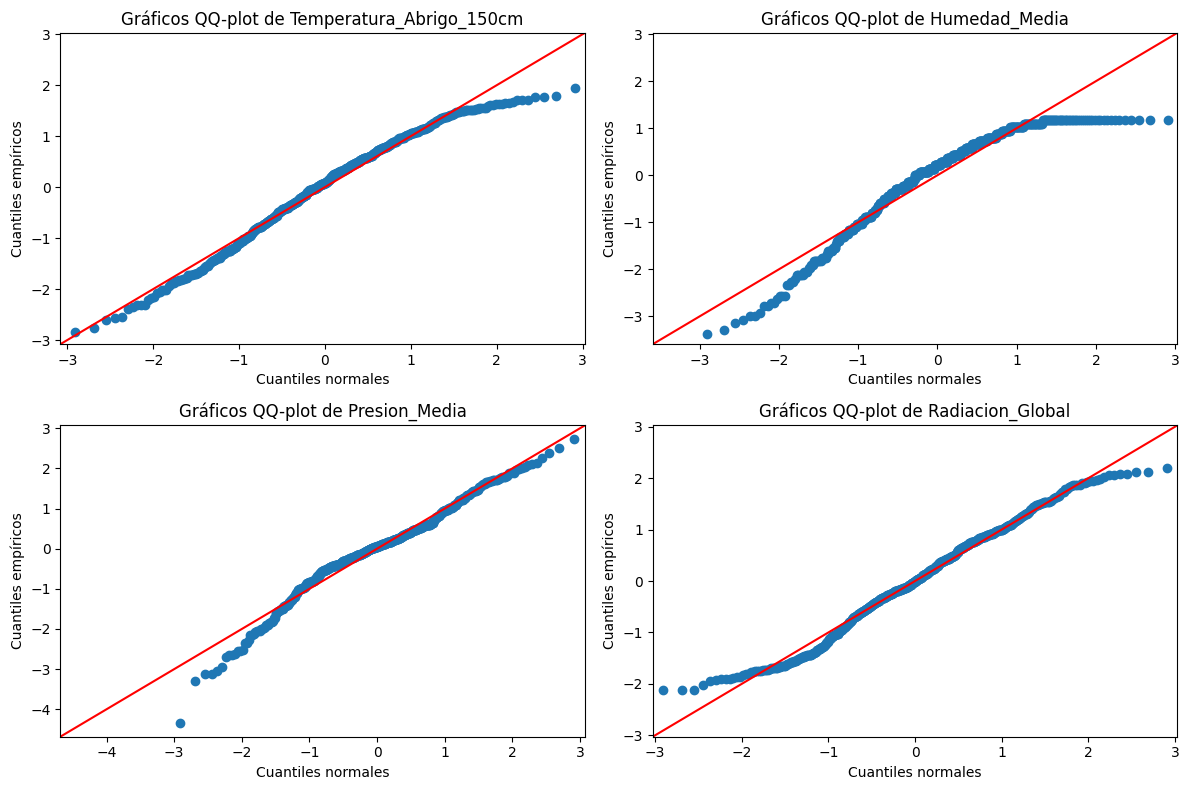

In [9]:
# ************************************
# VERIFICACIÓN GRÁFICA DE NORMALIDAD
# ************************************

# ************************************
#             QQPLOT
# ************************************

# Crear una figura con 4 subplots organizados en una cuadrícula de 2x2, para mejor visualización en el script
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten() #Se aplanan los subplots en un array unidimensional para poder iterar con el bucle.
                      #Esto se hace porque plt.subplots() devuelve una matriz dimensional y esto no se puede iterar.
for i, col in enumerate(columnas_numericas): #i es el índice de cada gráfico (0,1,2,3)
    sm.qqplot(df[col], line='45', fit=True, ax=axes[i]) #se indica que itere la función qqplot a cada
    axes[i].set_xlabel("Cuantiles normales")
    axes[i].set_ylabel("Cuantiles empíricos")
    axes[i].set_title(f"Gráficos QQ-plot de {col}")

plt.tight_layout()
plt.show()
plt.close() # Cierra la figura explícitamente

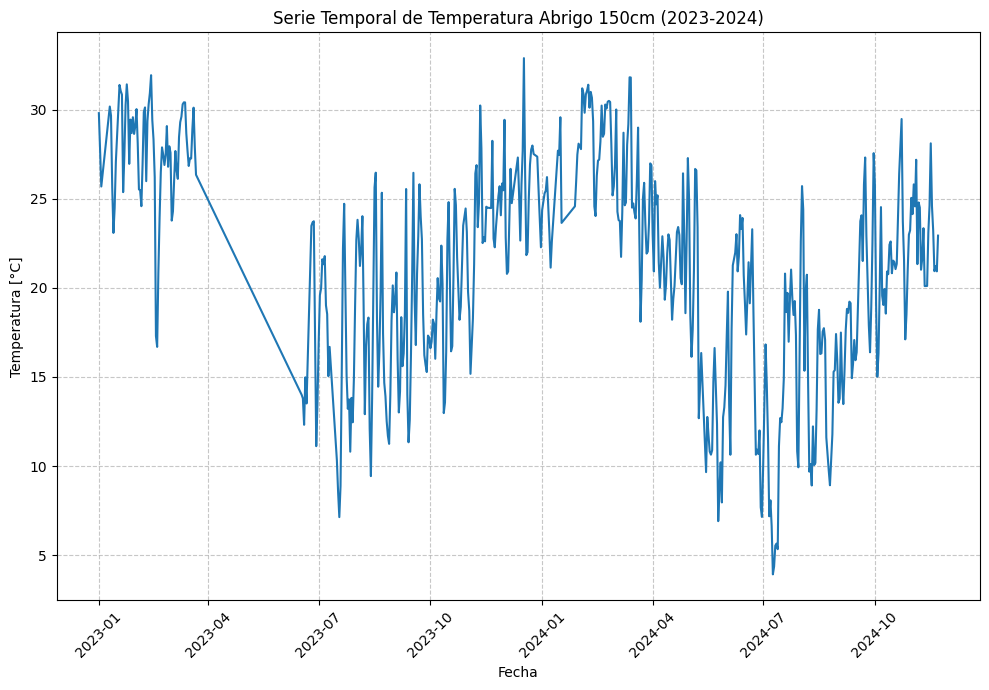

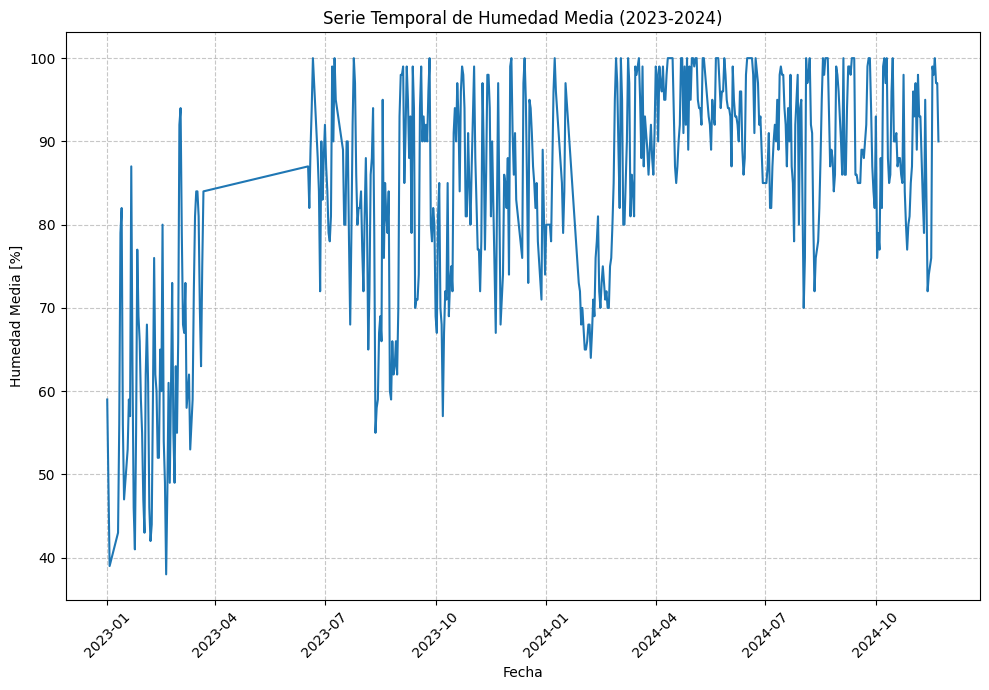

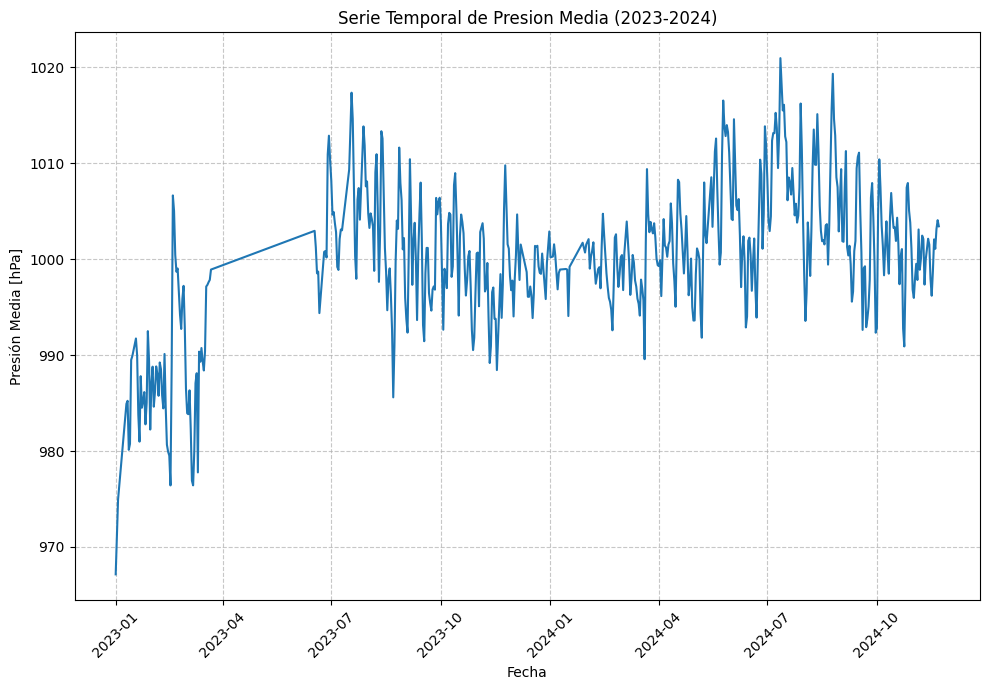

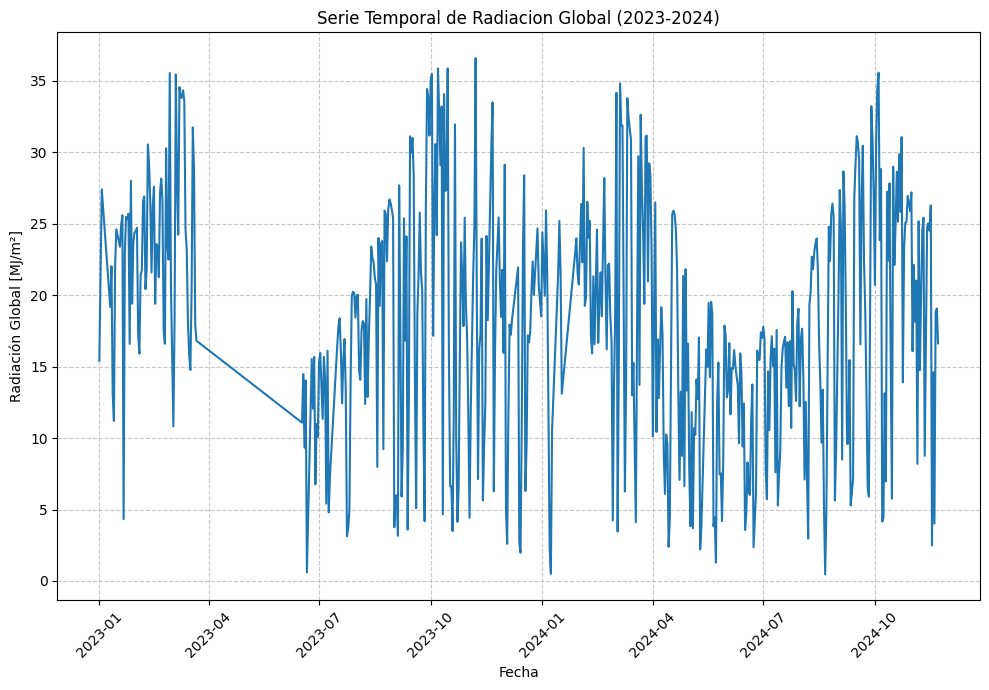

In [10]:
#********************************************
#   GRÁFICO DE SERIE TEMPORAL POR VARIABLE
#********************************************

for col in columnas_numericas:
    plt.figure(figsize=(10, 7))
    sns.lineplot(x='Fecha', y=col, data=df)
    plt.title(f'Serie Temporal de {col.replace("_", " ")} (2023-2024)')
    plt.xlabel('Fecha')
    # Ajustar etiqueta del eje Y según la variable
    if 'Temperatura' in col:
        plt.ylabel('Temperatura [°C]')
    elif 'Humedad' in col:
        plt.ylabel('Humedad Media [%]')
    elif 'Presion' in col:
        plt.ylabel('Presión Media [hPa]')
    elif 'Radiacion' in col:
        plt.ylabel('Radiación Global [MJ/m²]')
    else:
        plt.ylabel(col) # Etiqueta por defecto si no coincide con las anteriores

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## I-D — Verificación de representatividad estacional

**Objetivo:** cuantificar si el *gap* temporal detectado introduce un sesgo en la representación del otoño dentro del dataset.

In [11]:
# *************************************************************
# CUANTIFICACIÓN DEL SESGO ESTACIONAL GENERADO POR EL GAP
# Se compara la representación del otoño (meses 3, 4 y 5) entre
# 2023 y 2024 para verificar si el hueco de datos afecta el
# balance estacional del dataset.
# *************************************************************

df_ordenado['mes']  = df_ordenado['Fecha_dt'].dt.month   # Mes de cada registro (1 a 12)
df_ordenado['anio'] = df_ordenado['Fecha_dt'].dt.year    # Año de cada registro

otono = df_ordenado[df_ordenado['mes'].isin([3, 4, 5])].copy()   # Otoño en el hemisferio sur: marzo, abril y mayo

otono_2023 = otono[otono['anio'] == 2023]   # Registros de otoño correspondientes a 2023
otono_2024 = otono[otono['anio'] == 2024]   # Registros de otoño correspondientes a 2024

print("=" * 60)
print("  REPRESENTACIÓN DEL OTOÑO EN EL DATASET")
print("=" * 60)
print(f"  Total de registros de otoño (2023+2024): {len(otono)}")
print(f"  Otoño 2023: {len(otono_2023)} registros ({len(otono_2023)/len(otono)*100:.0f}%)")
print(f"  Otoño 2024: {len(otono_2024)} registros ({len(otono_2024)/len(otono)*100:.0f}%)")
print(f"  Rango de fechas de otoño 2023: {otono_2023['Fecha_dt'].min().date()} a {otono_2023['Fecha_dt'].max().date()}")
print()

# Comparación de temperatura media: ¿el otoño 2023 disponible es representativo?
media_2023 = otono_2023['Temperatura_Abrigo_150cm'].mean()
media_2024 = otono_2024['Temperatura_Abrigo_150cm'].mean()
t_stat, p_val = stats.ttest_ind(otono_2023['Temperatura_Abrigo_150cm'],
                                 otono_2024['Temperatura_Abrigo_150cm'])   # Test t para muestras independientes

print(f"  Temperatura media otoño 2023 (solo 1-22 marzo): {media_2023:.2f} °C")
print(f"  Temperatura media otoño 2024 (marzo-mayo completo): {media_2024:.2f} °C")
print(f"  Diferencia: {media_2023 - media_2024:.2f} °C")
print(f"  Test t: t={t_stat:.4f}, p-valor={p_val:.6f}")
print()
if p_val < 0.05:
    print("  CONCLUSIÓN: La diferencia es estadísticamente significativa.")
    print("  Los 22 registros de otoño 2023' corresponden climáticamente")
    print("  a la cola del verano (temperaturas altas), NO a la fase de")
    print("  enfriamiento real del otoño. El dataset subrepresenta esa")
    print("  transición estacional para el año 2023.")
else:
    print("  CONCLUSIÓN: No hay diferencia significativa entre ambos años.")


  REPRESENTACIÓN DEL OTOÑO EN EL DATASET
  Total de registros de otoño (2023+2024): 110
  Otoño 2023: 22 registros (20%)
  Otoño 2024: 88 registros (80%)
  Rango de fechas de otoño 2023: 2023-03-01 a 2023-03-22

  Temperatura media otoño 2023 (solo 1-22 marzo): 27.80 °C
  Temperatura media otoño 2024 (marzo-mayo completo): 20.95 °C
  Diferencia: 6.86 °C
  Test t: t=5.4931, p-valor=0.000000

  CONCLUSIÓN: La diferencia es estadísticamente significativa.
  Los 22 registros de otoño 2023' corresponden climáticamente
  a la cola del verano (temperaturas altas), NO a la fase de
  enfriamiento real del otoño. El dataset subrepresenta esa
  transición estacional para el año 2023.


---
######################################################################
# PARTE II — Regresión Lineal + Test de Hipótesis
######################################################################

Se modela la relación entre **Temperatura_Abrigo_150cm** (variable independiente x) y **Radiacion_Global** (variable dependiente y) por pedido de la consigna del trabajo.



## II-A — Regresión lineal simple

**Modelo:** y = β₀ + β₁·x + ε

donde β₀ es la ordenada al origen, β₁ es la pendiente, y ε es el error aleatorio.

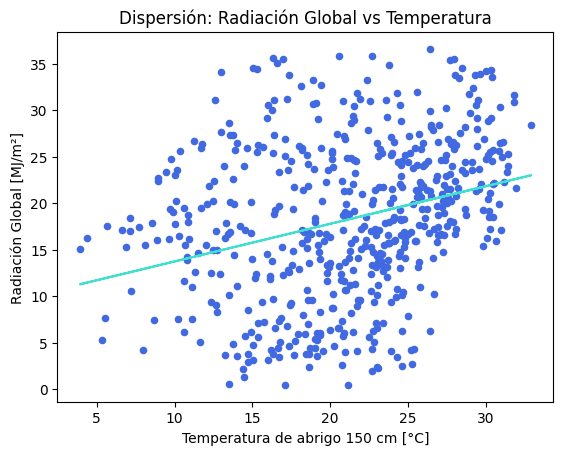

In [12]:
# ***********************************************
# SUPUESTO DE LINEALIDAD: GRÁFICO DE DISPERSIÓN: #
# TEMPERATURA vs RADIACIÓN                       #
# ***********************************************

plt.figure()                               # Se crea una nueva figura

# Se grafica cada observación como un punto: eje X = temperatura, eje Y = radiación
plt.scatter(df["Temperatura_Abrigo_150cm"], df["Radiacion_Global"], s=20, c="royalblue")
# s=20: tamaño de cada punto; c="royalblue": color de los puntos

# Se agrega la línea de tendencia lineal
# np.polyfit: calcula los coeficientes (pendiente e intercepto) del ajuste lineal de grado 1
# np.polyval: evalúa el polinomio resultante para obtener los valores de Y sobre la recta
plt.plot(
    df["Temperatura_Abrigo_150cm"],
    np.polyval(
        np.polyfit(df["Temperatura_Abrigo_150cm"], df["Radiacion_Global"], 1),
        df["Temperatura_Abrigo_150cm"]
    ),
    color='turquoise'                      # Color de la línea de tendencia
)

plt.title("Dispersión: Radiación Global vs Temperatura")
plt.xlabel("Temperatura de abrigo 150 cm [°C]")
plt.ylabel("Radiación Global [MJ/m²]")
plt.show()

In [13]:
# ************************************
#   REGRESIÓN LINEAL SIMPLE (OLS)
#   y = β₀ + β₁·x + ε
# ************************************

X = df[["Temperatura_Abrigo_150cm"]]     # Se selecciona la variable independiente u constante (predictora):Temperatura, como DataFrame

X = sm.add_constant(X)                    # Se agrega una columna de unos para que el modelo estime β₀ (ordenada al origen)
                                          # Sin este paso, el modelo forzaría la recta a pasar por el origen

Y = df[["Radiacion_Global"]]              # Se selecciona la variable dependiente (a predecir): Radiación Global

modelo = sm.OLS(Y, X).fit()               # OLS = Ordinary Least Squares (Mínimos Cuadrados Ordinarios)
                                          # .fit() ejecuta el ajuste del modelo (busca la mejor recta posible para explicar la relación entre X e Y) y devuelve los resultados

print(modelo.summary())                   # Se imprime el resumen completo del modelo:
                                          # - coeficientes β₀ y β₁
                                          # - R², R² ajustado
                                          # - estadísticos F y t
                                          # - p-valores e intervalos de confianza

                            OLS Regression Results                            
Dep. Variable:       Radiacion_Global   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     51.79
Date:                Fri, 26 Jun 2026   Prob (F-statistic):           2.03e-12
Time:                        16:23:45   Log-Likelihood:                -1936.5
No. Observations:                 554   AIC:                             3877.
Df Residuals:                     552   BIC:                             3886.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [14]:
# ************************************
# VISUALIZACIÓN DE LA RECTA AJUSTADA
# ************************************

# Se extraen los coeficientes estimados por el modelo
beta0 = modelo.params['const']                          # Ordenada al origen (β̂₀)
beta1 = modelo.params['Temperatura_Abrigo_150cm']       # Pendiente estimada (β̂₁)

# Se imprime la ecuación del modelo ajustado
print(f"Ecuación del modelo ajustado:")
print(f"  Radiacion_Global = {beta0:.4f} + {beta1:.4f} * Temperatura_Abrigo_150cm")
print()
print(f"Interpretación:")
print(f"  Por cada 1°C de aumento en la temperatura,")
print(f"  la radiación global aumenta en promedio {beta1:.4f} MJ/m².")

Ecuación del modelo ajustado:
  Radiacion_Global = 9.6899 + 0.4042 * Temperatura_Abrigo_150cm

Interpretación:
  Por cada 1°C de aumento en la temperatura,
  la radiación global aumenta en promedio 0.4042 MJ/m².


## II-B — Análisis de Residuos y Supuestos de las variables aleatorias

**¿Qué deben cumplir las variables aleatorias para que el modelo sea válido?**

Para que las conclusiones del test de hipótesis y la regresión sean válidas, los errores del modelo deben satisfacer los siguientes supuestos:

1. **Linealidad:** la relación entre X e Y debe ser lineal

2. **Homocedasticidad:** la varianza de los residuos debe ser constante (no depender de X) → se verifica gráficamente

3. **Normalidad:** los residuos deben seguir una distribución Normal → se verifica con Shapiro-Wilk y QQ-plot

4. **Independencia:** los residuos no deben estar autocorrelacionados → se verifica con el test de Durbin-Watson

In [15]:
# *************************************************************
# PREPARACIÓN PARA EL ANÁLISIS DE SUPUESTOS
# A partir del modelo ajustado en II-A se calculan los valores
# ajustados, los residuos estandarizados y la distancia de Cook
# de cada observación. Estas cantidades se usan en los gráficos
# de diagnóstico de esta sección.
# *************************************************************

influence = OLSInfluence(modelo)                                  # Objeto con medidas de influencia del modelo OLS
valores_ajustados = modelo.fittedvalues                           # Valores predichos (y) por el modelo
residuos_estandarizados = influence.resid_studentized_internal    # Residuos divididos por su desvío estándar estimado
distancia_cook = influence.cooks_distance[0]                       # Distancia de Cook de cada observación


In [16]:
# ************************************
# SUPUESTO: NORMALIDAD DE RESIDUOS
# Test de Shapiro-Wilk sobre los residuos del modelo
# H₀: los residuos siguen distribución Normal (Campana y distribuidos alrededor de cero)
# H₁: los residuos NO siguen distribución Normal
# ************************************

residuo = modelo.resid                                 # Se obtienen los residuos crudos del modelo

w_test, p_value = stats.shapiro(residuo)               # stats.shapiro devuelve el estadístico W y el p-valor
# Estadístico W: cercano a 1 indica mayor normalidad
# p-valor: si es mayor que α (0.05), no se rechaza normalidad

print("=" * 55)
print("  SUPUESTO 1: NORMALIDAD — Test de Shapiro-Wilk")
print("=" * 55)
print(f"  Estadístico W:  {w_test:.4f}")
print(f"  p-valor:        {p_value:.4f}")
print()
if p_value > 0.05:
    print("  CONCLUSIÓN: No se rechaza H₀ → los residuos son")
    print("  consistentes con una distribución Normal (α = 0.05).")
    print("  El supuesto de normalidad se cumple.")
else:
    print("  CONCLUSIÓN: Se rechaza H₀ → los residuos no siguen")
    print("  estrictamente una distribución Normal.")
    print("  Nota: con muestras grandes (n > 300) el test es muy")
    print("  sensible. Se recomienda evaluar también el QQ-plot.")

  SUPUESTO 1: NORMALIDAD — Test de Shapiro-Wilk
  Estadístico W:  0.9915
  p-valor:        0.0029

  CONCLUSIÓN: Se rechaza H₀ → los residuos no siguen
  estrictamente una distribución Normal.
  Nota: con muestras grandes (n > 300) el test es muy
  sensible. Se recomienda evaluar también el QQ-plot.


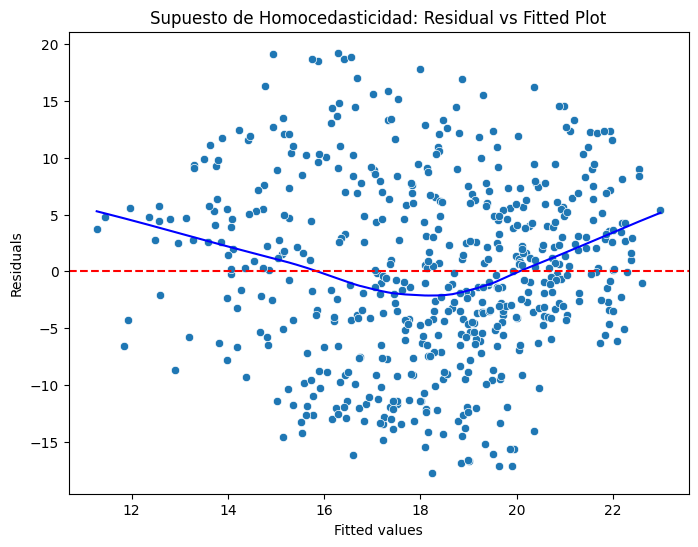

Si los puntos se dispersan aleatoriamente alrededor de 0 sin patrón
tipo embudo o curva, el supuesto de homocedasticidad se cumple.


In [17]:
# ***********************************************************
# SUPUESTO: HOMOCEDASTICIDAD: Varianza de errores constante
# Gráfico de residuos vs valores ajustados con suavizado LOESS
# ************************************************************

fitted  = modelo.fittedvalues                          # Valores predichos por el modelo (ŷ)
residuo = modelo.resid                                 # Residuos del modelo

plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted, y=residuo)                   # Cada punto es una observación

# Suavizado LOESS: ajusta una curva flexible sin asumir forma paramétrica
# Si la curva es aproximadamente horizontal en y=0, se cumple homocedasticidad
lowess    = sm.nonparametric.lowess                    # Se usa el LOESS de statsmodels (igual que Celeste)
suavizado = lowess(residuo, fitted)                    # Calcula el suavizado: (residuos, valores ajustados)
plt.plot(suavizado[:, 0], suavizado[:, 1], color='blue')  # Se grafíca la curva suavizada

plt.axhline(y=0, color='red', linestyle='dashed')      # Línea de referencia en y = 0
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Supuesto de Homocedasticidad: Residual vs Fitted Plot")
sns.set_theme(style="whitegrid")
plt.show()
print("Si los puntos se dispersan aleatoriamente alrededor de 0 sin patrón")
print("tipo embudo o curva, el supuesto de homocedasticidad se cumple.")

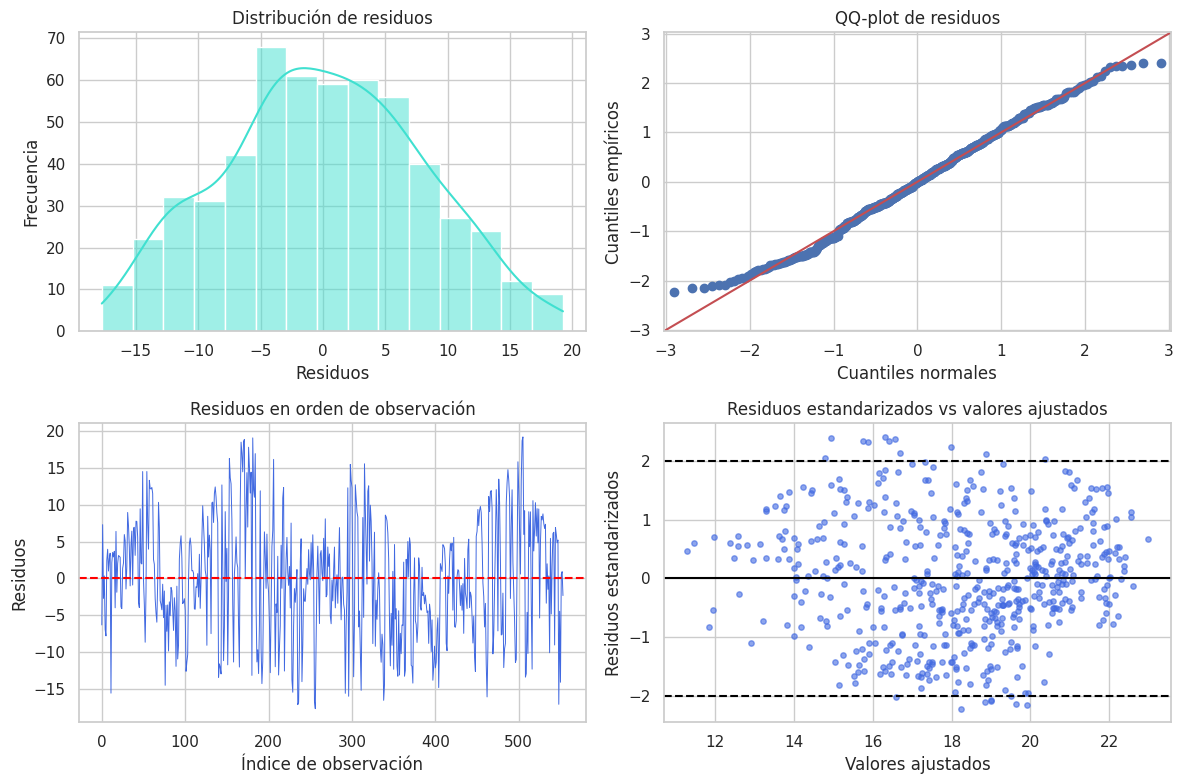

  RESUMEN DE SUPUESTOS DEL MODELO
  1. Normalidad (Shapiro-Wilk):   Verificar p-valor anterior
  2. Homocedasticidad:            Verificar gráfico Residual vs Fitted
  3. Independencia:               Verificar residuos en el tiempo
  4. Linealidad:                  Verificar gráfico de dispersión Parte II-A


In [18]:
# *******************************************************************
# RESUMEN VISUAL DE SUPUESTOS (normalidad, independencia, atípicos)
# Esta celda arma una grilla de 4 gráficos que cubre varios supuestos
# a la vez (no solo independencia): histograma y QQ-plot de residuos
# para normalidad, residuos en el tiempo para independencia, y
# residuos estandarizados vs ajustados para detectar atípicos.
# ******************************************************************

# QQ-plot de los residuos: compara cuantiles empíricos vs teóricos de la Normal
fig, axes = plt.subplots(2, 2, figsize=(12, 8))        # Cuadrícula 2x2 para los 4 supuestos visuales
axes = axes.flatten()                                   # Se aplana para poder iterar con índice numérico


# Gráfico 1: Histograma de residuos
sns.histplot(residuo, kde=True, bins=15, color='turquoise', ax=axes[0])
axes[0].set_title('Distribución de residuos')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Frecuencia')


# Gráfico 2: QQ-plot de residuos
sm.qqplot(residuo, line='45', fit=True, ax=axes[1])    # line='45' dibuja la diagonal de referencia
                                                        # fit=True ajusta media y desvío a los datos
axes[1].set_title('QQ-plot de residuos')
axes[1].set_xlabel('Cuantiles normales')
axes[1].set_ylabel('Cuantiles empíricos')


# Gráfico 3: Residuos en el tiempo (para verificar independencia)
axes[2].plot(range(len(residuo)), residuo, color='royalblue', linewidth=0.7)
axes[2].axhline(y=0, color='red', linestyle='dashed')
axes[2].set_title('Residuos en orden de observación')
axes[2].set_xlabel('Índice de observación')
axes[2].set_ylabel('Residuos')


# Gráfico 4: Residuos estandarizados vs valores ajustados
axes[3].scatter(valores_ajustados, residuos_estandarizados, s=15, color='royalblue', alpha=0.6)
axes[3].axhline(y= 2, linestyle='dashed', linewidth=1.5, color='black')
axes[3].axhline(y=-2, linestyle='dashed', linewidth=1.5, color='black')
axes[3].axhline(y= 0, color='black')
axes[3].set_title('Residuos estandarizados vs valores ajustados')
axes[3].set_xlabel('Valores ajustados')
axes[3].set_ylabel('Residuos estandarizados')
# Interpretación: los puntos fuera de ±2 son observaciones atípicas: OJO REVISAR!!!
# Se espera que aproximadamente el 95% de los puntos quede dentro de ±2

plt.tight_layout()
plt.show()

# Resumen del estado de los supuestos
print("=" * 55)
print("  RESUMEN DE SUPUESTOS DEL MODELO")
print("=" * 55)
print(f"  1. Normalidad (Shapiro-Wilk):   {'Verificar p-valor anterior'}")
print(f"  2. Homocedasticidad:            Verificar gráfico Residual vs Fitted")
print(f"  3. Independencia:               Verificar residuos en el tiempo")
print(f"  4. Linealidad:                  Verificar gráfico de dispersión Parte II-A")

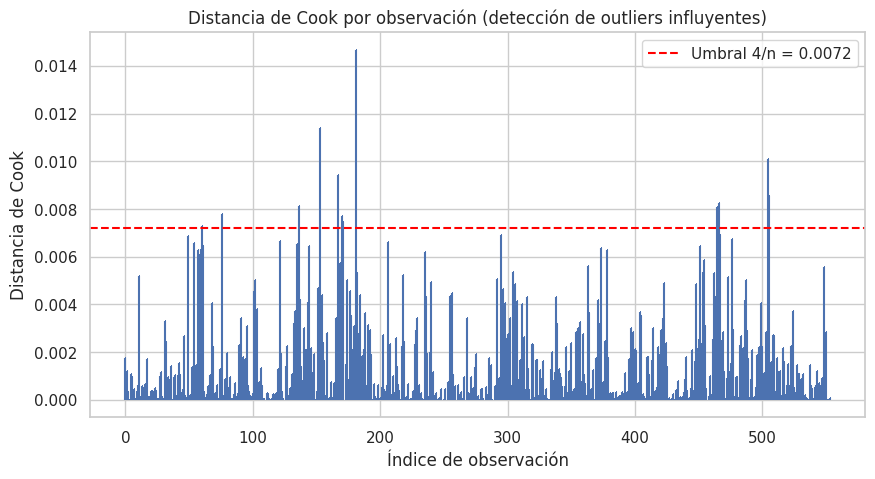

  DISTANCIA DE COOK — Observaciones influyentes
  n (cantidad de observaciones):        554
  Umbral de referencia (4/n):           0.0072
  Observaciones que superan el umbral:  12 (2.2%)

  Interpretación: una distancia de Cook mayor a 4/n indica que
  esa observación, por sí sola, tiene una influencia importante
  sobre los coeficientes estimados (β₀ y β₁) del modelo. No
  significa necesariamente que sea un error de medición, pero
  conviene revisarla. Si el porcentaje de observaciones que
  superan el umbral es bajo (cercano al 5% esperado bajo
  comportamiento normal), el modelo es robusto y ninguna
  observación individual domina el resultado.


In [19]:
# *************************************************************
# SUPUESTO: OBSERVACIONES INFLUYENTES — DISTANCIA DE COOK
# Mide cuánto cambian los coeficientes del modelo si se elimina
# cada observación de forma individual
# Umbral de referencia habitual: 4/n
# *************************************************************

n_obs = len(df)                            # Cantidad total de observaciones
umbral_cook = 4 / n_obs                    # Umbral de referencia 4/n para la distancia de Cook

plt.figure(figsize=(10, 5))
plt.stem(range(n_obs), distancia_cook, markerfmt=",", basefmt=" ")  # Gráfico de "palitos" por observación
plt.axhline(y=umbral_cook, color='red', linestyle='dashed', linewidth=1.5,
            label=f'Umbral 4/n = {umbral_cook:.4f}')
plt.xlabel('Índice de observación')
plt.ylabel('Distancia de Cook')
plt.title('Distancia de Cook por observación (detección de outliers influyentes)')
plt.legend()
plt.show()

# Cantidad de observaciones que superan el umbral 4/n
obs_influyentes  = np.sum(distancia_cook > umbral_cook)
porc_influyentes = obs_influyentes / n_obs * 100

print("=" * 55)
print("  DISTANCIA DE COOK — Observaciones influyentes")
print("=" * 55)
print(f"  n (cantidad de observaciones):        {n_obs}")
print(f"  Umbral de referencia (4/n):           {umbral_cook:.4f}")
print(f"  Observaciones que superan el umbral:  {obs_influyentes} ({porc_influyentes:.1f}%)")
print()
print("  Interpretación: una distancia de Cook mayor a 4/n indica que")
print("  esa observación, por sí sola, tiene una influencia importante")
print("  sobre los coeficientes estimados (β₀ y β₁) del modelo. No")
print("  significa necesariamente que sea un error de medición, pero")
print("  conviene revisarla. Si el porcentaje de observaciones que")
print("  superan el umbral es bajo (cercano al 5% esperado bajo")
print("  comportamiento normal), el modelo es robusto y ninguna")
print("  observación individual domina el resultado.")


## II-C — EVALUACIÓN DEL MODELO DE REGRESIÓN LINEAL SIMPLE: Coeficiente de determinación R²

**Objetivo:** medir qué proporción de la variabilidad de Y es explicada por el modelo.

R² = SSR / SST = 1 − SSE / SST, donde SST es la variabilidad total, SSR la explicada y SSE la residual.

In [20]:
# ******************************************************
# EVALUACIÓN DEL MODELO: COEFICIENTE DE DETERMINACIÓN R²
# ******************************************************

# Se reutiliza el mismo modelo ajustado en II-A
resultados = modelo.summary()
print(resultados)                          # El R² aparece en la línea "R-squared" del resumen

# Se extrae el R² directamente del objeto del modelo
R2 = modelo.rsquared
print(f"Coeficiente de determinación R²: {R2:.4f}")
print()
print(f"Interpretación: el modelo de regresión lineal simple explica el")
print(f"{R2*100:.2f}% de la variabilidad total de la Radiación Global.")

                            OLS Regression Results                            
Dep. Variable:       Radiacion_Global   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     51.79
Date:                Fri, 26 Jun 2026   Prob (F-statistic):           2.03e-12
Time:                        16:23:48   Log-Likelihood:                -1936.5
No. Observations:                 554   AIC:                             3877.
Df Residuals:                     552   BIC:                             3886.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

## II-D — Test de hipótesis sobre la pendiente β₁

**Objetivo:** determinar si la relación lineal entre Temperatura y Radiación es estadísticamente significativa.

**Planteo del test:**

| | |
|---|---|
| **H₀:** | β₁ = 0 → la pendiente es nula → no existe relación lineal |
| **H₁:** | β₁ ≠ 0 → la pendiente es distinta de cero → existe relación lineal |
| **Tipo de test:** | Bilateral (dos colas) |
| **Nivel de significancia:** | α = 0.05 |
| **Estadístico de prueba:** | T₀ = β̂₁ / √(σ̂² / Sxx) ~ t(n−2) bajo H₀ |
| **Supuesto:** | los errores ε siguen distribución Normal, son independientes y tienen varianza constante |

**Regla de decisión:** se rechaza H₀ si |T₀| > t(α/2, n−2) o equivalentemente si p-valor < α

In [21]:
# ************************************
# TEST DE HIPÓTESIS SOBRE LA PENDIENTE β₁
# H₀: β₁ = 0   vs   H₁: β₁ ≠ 0
# ************************************

xi = df["Temperatura_Abrigo_150cm"].values   # Se extraen los valores de X como array de NumPy
yi = df["Radiacion_Global"].values            # Se extraen los valores de Y como array de NumPy
n  = len(xi)                                  # Tamaño de la muestra

# --- Cantidades auxiliares para los estimadores ---
Sxx = np.sum(xi**2) - (np.sum(xi)**2) / n           # Suma de cuadrados centrados de X
                                                      # Sxx = Σ(xi - x̄)²  (forma computacional)
Sxy = np.sum(xi * yi) - (np.sum(xi) * np.sum(yi)) / n  # Suma de productos cruzados centrados
                                                         # Sxy = Σ(xi - x̄)(yi - ȳ)
SST = np.sum(yi**2) - n * (np.mean(yi)**2)           # Variabilidad total de Y
                                                      # SST = Σ(yi - ȳ)²

# --- Estimadores de los parámetros ---
beta1_est    = Sxy / Sxx                              # Estimador de β₁ (pendiente) por mínimos cuadrados
SSE          = SST - beta1_est * Sxy                  # Error cuadrático residual: SSE = SST - β̂₁·Sxy
varSigma_est = SSE / (n - 2)                          # Estimador de σ² (varianza del error); se divide por n-2 (grados de libertad)

# --- Estadístico de prueba ---
T0      = beta1_est / np.sqrt(varSigma_est / Sxx)    # T₀ = β̂₁ / SE(β̂₁); sigue distribución t con n-2 grados de libertad
p_valor = 2 * (1 - stats.t.cdf(np.abs(T0), df=n-2)) # p-valor bilateral: P(|t| > |T₀|)
                                                      # stats.t.cdf: función de distribución acumulada de la t de Student

# --- Valor crítico ---
alpha     = 0.05                                      # Nivel de significancia
t_critico = stats.t.ppf(1 - alpha/2, df=n-2)         # Valor crítico: t tal que P(t > t_crit) = α/2
                                                      # stats.t.ppf: función inversa de la distribución t

# Coeficiente de correlación muestral de Pearson (calculado manualmente)
r      = Sxy / np.sqrt(Sxx * SST)                    # r = Sxy / √(Sxx · SST)
T0r    = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)      # Estadístico t para r; equivalente a T0 sobre β₁
p_valR = 2 * (1 - stats.t.cdf(np.abs(T0r), df=n-2)) # p-valor bilateral para r

# --- Resultados del test ---
print("=" * 60)
print("   TEST DE HIPÓTESIS SOBRE LA PENDIENTE β₁")
print("=" * 60)
print(f"  n (tamaño muestral):           {n}")
print(f"  Sxx:                           {Sxx:.4f}")
print(f"  Sxy:                           {Sxy:.4f}")
print(f"  SST:                           {SST:.4f}")
print(f"  β̂₁ (pendiente estimada):       {beta1_est:.6f}")
print(f"  σ̂² (varianza residual est.):   {varSigma_est:.6f}")
print()
print(f"  Estadístico T₀:                {T0:.4f}")
print(f"  Valor crítico ±t(α/2, n-2):   ±{t_critico:.4f}")
print(f"  p-valor:                       {p_valor:.4e}")
print(f"  Nivel de significancia α:      {alpha}")
print()
print(f"  r de Pearson (manual):         {r:.8f}")
print(f"  p-valor de r:                  {p_valR:.4e}")
print()

# --- Verificación con scipy ---
pearson_r, p_pearson = stats.pearsonr(xi, yi)        # Verificación automática con scipy
print(f"  r de Pearson (scipy):          {pearson_r:.8f}, p-valor: {p_pearson:.4e}")
print()

# --- Decisión y conclusión ---
print("  REGIÓN DE RECHAZO: |T₀| > t_crítico")
if abs(T0) > t_critico:
    print(f"  |T₀| = {abs(T0):.4f} > t_crit = {t_critico:.4f}  →  Se RECHAZA H₀")
else:
    print(f"  |T₀| = {abs(T0):.4f} ≤ t_crit = {t_critico:.4f}  →  No se rechaza H₀")
print()
if p_valor < alpha:
    print(f"  DECISIÓN: Se RECHAZA H₀ (p-valor = {p_valor:.4e} < α = {alpha})")
    print("  CONCLUSIÓN: Existe evidencia estadística suficiente para afirmar")
    print("  que la pendiente β₁, es significativamente distinta de cero (HIPOTESIS ALTERNATIVA H1).")
    print("  Es decir, la Temperatura tiene un efecto lineal estadísticamente")
    print("  significativo sobre la Radiación Global.")
else:
    print(f"  DECISIÓN: No se rechaza H₀ (p-valor = {p_valor:.4e} ≥ α = {alpha})")
    print("  CONCLUSIÓN: No hay evidencia suficiente para afirmar relación lineal.")

   TEST DE HIPÓTESIS SOBRE LA PENDIENTE β₁
  n (tamaño muestral):           554
  Sxx:                           20242.9936
  Sxy:                           8181.5578
  SST:                           38554.5454
  β̂₁ (pendiente estimada):       0.404167
  σ̂² (varianza residual est.):   63.854758

  Estadístico T₀:                7.1962
  Valor crítico ±t(α/2, n-2):   ±1.9643
  p-valor:                       2.0315e-12
  Nivel de significancia α:      0.05

  r de Pearson (manual):         0.29286053
  p-valor de r:                  2.0315e-12

  r de Pearson (scipy):          0.29286053, p-valor: 2.0314e-12

  REGIÓN DE RECHAZO: |T₀| > t_crítico
  |T₀| = 7.1962 > t_crit = 1.9643  →  Se RECHAZA H₀

  DECISIÓN: Se RECHAZA H₀ (p-valor = 2.0315e-12 < α = 0.05)
  CONCLUSIÓN: Existe evidencia estadística suficiente para afirmar
  que la pendiente β₁, es significativamente distinta de cero (HIPOTESIS ALTERNATIVA H1).
  Es decir, la Temperatura tiene un efecto lineal estadísticamente
  signif

## II-E — Análisis de sensibilidad ante la limitación temporal

**Objetivo:** evaluar cuánto cambia la estimación de la pendiente β₁ si se excluyen del modelo los 22 registros de "otoño 2023" identificados en la sección I-E como climáticamente no representativos (cola del verano, no transición otoñal real).

Esto **no es un test de hipótesis adicional**: es un análisis de robustez que permite cuantificar qué tan sensible es la conclusión del modelo a la limitación de cobertura temporal detectada en los datos.

In [22]:
# *************************************************************
# ANÁLISIS DE SENSIBILIDAD: MODELO CON Y SIN "OTOÑO 2023"
# Se reajusta la regresión excluyendo los 22 registros del
# 1 al 22 de marzo de 2023 (la única porción de otoño 2023
# disponible, climáticamente no representativa) para medir
# el impacto sobre β₁ y R².
# *************************************************************

mascara_excluir = (df_ordenado['anio'] == 2023) & (df_ordenado['mes'] == 3) & (df_ordenado['Fecha_dt'].dt.day <= 22)
df_sin_otono23 = df_ordenado[~mascara_excluir]    # Dataset excluyendo esos 22 registros puntuales

# --- Modelo de referencia: con todos los datos (igual al de II-A) ---
X_full = sm.add_constant(df_ordenado[['Temperatura_Abrigo_150cm']])
modelo_full = sm.OLS(df_ordenado['Radiacion_Global'], X_full).fit()

# --- Modelo alternativo: excluyendo los 22 registros no representativos ---
X_sin = sm.add_constant(df_sin_otono23[['Temperatura_Abrigo_150cm']])
modelo_sin = sm.OLS(df_sin_otono23['Radiacion_Global'], X_sin).fit()

beta1_full = modelo_full.params['Temperatura_Abrigo_150cm']
beta1_sin  = modelo_sin.params['Temperatura_Abrigo_150cm']
cambio_pct = abs(beta1_sin - beta1_full) / beta1_full * 100   # Variación porcentual de la pendiente

print("=" * 65)
print("  COMPARACIÓN: MODELO COMPLETO vs MODELO SIN OTOÑO 2023")
print("=" * 65)
print(f"  {'':25s} {'Con todos los datos':>20s} {'Sin otoño 2023':>20s}")
print(f"  {'n (observaciones)':25s} {len(df_ordenado):>20d} {len(df_sin_otono23):>20d}")
print(f"  {'β₁ (pendiente)':25s} {beta1_full:>20.4f} {beta1_sin:>20.4f}")
print(f"  {'R²':25s} {modelo_full.rsquared:>20.4f} {modelo_sin.rsquared:>20.4f}")
print()
print(f"  Cambio en β₁: {cambio_pct:.1f}%")
print()
print("  INTERPRETACIÓN:")
print("  En ambos casos se rechaza H₀ con p-valor muy bajo, por lo que")
print("  la conclusión cualitativa (existe relación lineal significativa)")
print("  NO cambia. Sin embargo, la pendiente estimada SÍ es sensible")
print("  (~9%) a qué observaciones de la transición estacional están")
print("  presentes en los datos. Como la franja de temperaturas")
print("  templadas-frías depende casi en su totalidad de 2024, no es")
print("  posible saber si 2023 hubiera mostrado una relación Temperatura-")
print("  Radiación distinta en esa misma franja (por ejemplo, ante un")
print("  evento climático particular de ese año).")
print()
print("  CONCLUSIÓN METODOLÓGICA:")
print("  El modelo es razonablemente robusto en su conclusión general,")
print("  pero la representatividad climática está condicionada por la")
print("  ausencia casi total de observaciones de 2023 en la transición")
print("  otoño-invierno. Esta limitación se documenta como parte de la")
print("  validez del análisis.")


  COMPARACIÓN: MODELO COMPLETO vs MODELO SIN OTOÑO 2023
                             Con todos los datos       Sin otoño 2023
  n (observaciones)                          554                  532
  β₁ (pendiente)                          0.4042               0.3670
  R²                                      0.0858               0.0709

  Cambio en β₁: 9.2%

  INTERPRETACIÓN:
  En ambos casos se rechaza H₀ con p-valor muy bajo, por lo que
  la conclusión cualitativa (existe relación lineal significativa)
  NO cambia. Sin embargo, la pendiente estimada SÍ es sensible
  (~9%) a qué observaciones de la transición estacional están
  presentes en los datos. Como la franja de temperaturas
  templadas-frías depende casi en su totalidad de 2024, no es
  posible saber si 2023 hubiera mostrado una relación Temperatura-
  Radiación distinta en esa misma franja (por ejemplo, ante un
  evento climático particular de ese año).

  CONCLUSIÓN METODOLÓGICA:
  El modelo es razonablemente robusto en su con

## II-F — Regresión lineal múltiple

Se incorporan **Temperatura_Abrigo_150cm**, **Humedad_Media** y **Presion_Media** como variables independientes para predecir **Radiacion_Global**.

**Modelo:** Y = β₀ + β₁·X₁ + β₂·X₂ + β₃·X₃ + ε

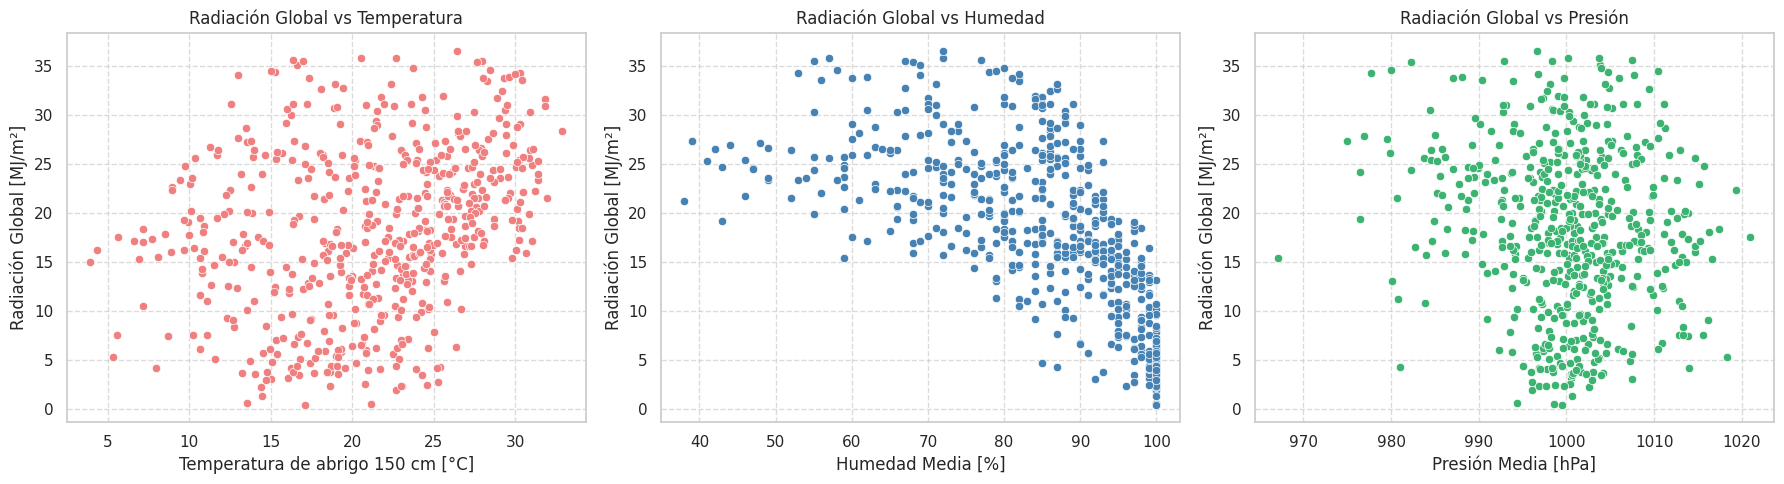

In [23]:
# **************************************************************
# VISUALIZACIÓN DE RELACIÓN ENTRE VARIABLES INDEP Y RAD GLOBAL
# **************************************************************

fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # 1 fila, 3 columnas para los 3 gráficos

# Gráfico 1: Temperatura vs Radiación Global
sns.scatterplot(x='Temperatura_Abrigo_150cm', y='Radiacion_Global', data=df, ax=axes[0], color='lightcoral')
axes[0].set_title('Radiación Global vs Temperatura')
axes[0].set_xlabel('Temperatura de abrigo 150 cm [°C]')
axes[0].set_ylabel('Radiación Global [MJ/m²]')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Humedad vs Radiación Global
sns.scatterplot(x='Humedad_Media', y='Radiacion_Global', data=df, ax=axes[1], color='steelblue')
axes[1].set_title('Radiación Global vs Humedad')
axes[1].set_xlabel('Humedad Media [%]')
axes[1].set_ylabel('Radiación Global [MJ/m²]')
axes[1].grid(True, linestyle='--', alpha=0.7)

# Gráfico 3: Presión vs Radiación Global
sns.scatterplot(x='Presion_Media', y='Radiacion_Global', data=df, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Radiación Global vs Presión')
axes[2].set_xlabel('Presión Media [hPa]')
axes[2].set_ylabel('Radiación Global [MJ/m²]')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout() # Ajusta automáticamente el espaciado
plt.show()

In [24]:
# ************************************
# REGRESIÓN LINEAL MÚLTIPLE
# y  = Radiacion_Global (variable dependiente)
# x1 = Temperatura_Abrigo_150cm
# x2 = Humedad_Media
# x3 = Presion_Media
# ************************************

# Se seleccionan las tres variables predictoras
x_mult = df[["Temperatura_Abrigo_150cm", "Humedad_Media", "Presion_Media"]]
x_mult = sm.add_constant(x_mult)           # Se agrega el término independiente β₀

y_mult = df["Radiacion_Global"]            # Variable dependiente (la misma que en el modelo simple)

modelo_mult = sm.OLS(y_mult, x_mult).fit() # Se ajusta el modelo con las tres variables predictoras
print(modelo_mult.summary())               # Resumen completo del modelo múltiple

                            OLS Regression Results                            
Dep. Variable:       Radiacion_Global   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.455
Method:                 Least Squares   F-statistic:                     154.9
Date:                Fri, 26 Jun 2026   Prob (F-statistic):           9.41e-73
Time:                        16:23:49   Log-Likelihood:                -1791.7
No. Observations:                 554   AIC:                             3591.
Df Residuals:                     550   BIC:                             3609.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

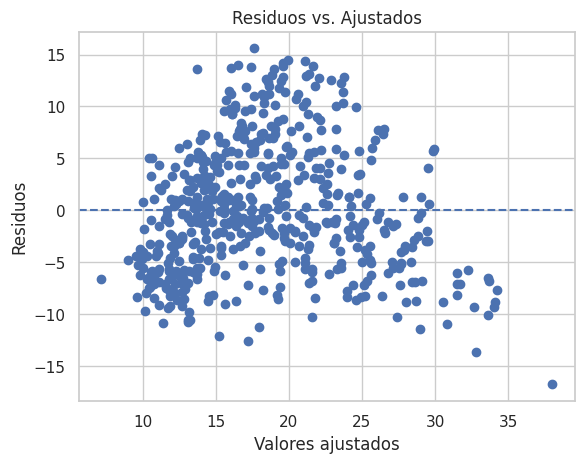

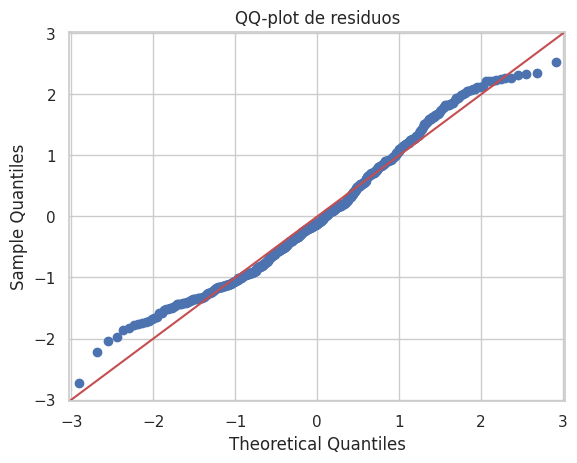

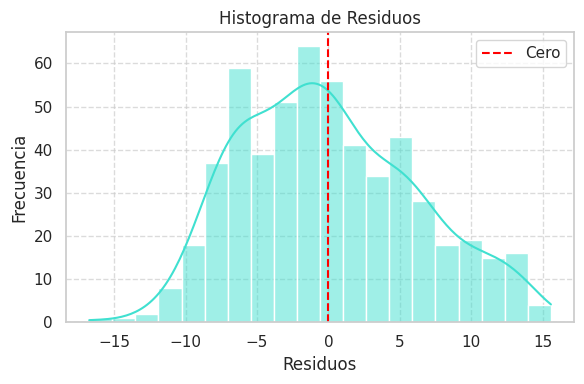

In [25]:
# ************************************
# DIAGNÓSTICO VISUAL DE RESIDUOS
# ************************************

fitted = modelo_mult.fittedvalues
resid = modelo_mult.resid

# Residuos vs. ajustados
plt.figure()
plt.scatter(fitted, resid)
plt.axhline(0, linestyle="--")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs. Ajustados")
plt.show()

# QQ-plot de residuos
sm.qqplot(resid, line="45", fit=True)
plt.title("QQ-plot de residuos")
plt.show()

# Histograma de residuos

plt.figure(figsize=(6, 4))
sns.histplot(modelo_mult.resid, kde=True, bins=20, color='turquoise')
plt.title('Histograma de Residuos')
plt.xlabel('Residuos')
plt.ylabel('Frecuencia')
plt.axvline(0, color='red', linestyle='--', label='Cero')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [26]:
# **************************************************************
# EVALUACIÓN DE MULTICOLINEALIDAD
# Se verifica mediante Factor de inflación de la varianza (VIF)
# **************************************************************

x_mult_vif = x_mult.copy() #Se realizó una copia para no modificar el original

vif_data = pd.DataFrame()
vif_data['Variable'] = x_mult_vif.columns
vif_data['VIF'] = [variance_inflation_factor(x_mult_vif.values, i) for i in range(x_mult_vif.shape[1])]

display(vif_data)

print("\nInterpretación del VIF:")
print("  - VIF = 1: No hay correlación entre la variable y las demás predictoras.")
print("  - VIF > 1 y < 5: Baja multicolinealidad (generalmente aceptable).")
print("  - VIF > 5 y < 10: Multicolinealidad moderada (puede ser preocupante, requiere atención).")
print("  - VIF > 10: Multicolinealidad alta (problemática, sugiere que la variable es redundante o está fuertemente relacionada con otras).")

,Variable,VIF
0,const,39882.752807
1,Temperatura_Abrigo_150cm,2.295195
2,Humedad_Media,1.193412
3,Presion_Media,2.249964



Interpretación del VIF:
  - VIF = 1: No hay correlación entre la variable y las demás predictoras.
  - VIF > 1 y < 5: Baja multicolinealidad (generalmente aceptable).
  - VIF > 5 y < 10: Multicolinealidad moderada (puede ser preocupante, requiere atención).
  - VIF > 10: Multicolinealidad alta (problemática, sugiere que la variable es redundante o está fuertemente relacionada con otras).


In [27]:
# **************************************************************
# EVALUACIÓN DE HOMOCEDASTICIDAD
# Se verifica mediante test de Breusch–Pagan
# **************************************************************

# Los residuos del modelo de regresión múltiple
resid_mult = modelo_mult.resid

# parametros: resid, exog_het (variables explicativas)
lm, lm_pvalue, fvalue, f_pvalue = het_breuschpagan(resid_mult, x_mult)

print("*" * 60)
print("   TEST DE BREUSCH-PAGAN PARA HOMOCEDASTICIDAD")
print("*" * 60)
print(f"  Estadístico LM:                        {lm:.4f}")
print(f"  p-valor (LM):                         {lm_pvalue:.4f}")
print(f"  Estadístico F:                        {fvalue:.4f}")
print(f"  p-valor (F):                          {f_pvalue:.4f}")
print("\nInterpretación:")
if lm_pvalue < 0.05:
    print(f"  Como el p-valor ({lm_pvalue:.4f}) es menor que 0.05, se RECHAZA la hipótesis nula de homocedasticidad.")
    print("  Esto sugiere que existe HETEROCEDASTICIDAD en los residuos del modelo.")
    print("  La varianza de los errores no es constante y puede depender de las variables independientes.")
    print("  Esto puede afectar la validez de los intervalos de confianza y los tests de significancia.")
else:
    print(f"  Como el p-valor ({lm_pvalue:.4f}) es mayor o igual que 0.05, NO se rechaza la hipótesis nula de homocedasticidad.")
    print("  Esto sugiere que el supuesto de homocedasticidad se cumple en los residuos del modelo.")


************************************************************
   TEST DE BREUSCH-PAGAN PARA HOMOCEDASTICIDAD
************************************************************
  Estadístico LM:                        10.8428
  p-valor (LM):                         0.0126
  Estadístico F:                        3.6598
  p-valor (F):                          0.0124

Interpretación:
  Como el p-valor (0.0126) es menor que 0.05, se RECHAZA la hipótesis nula de homocedasticidad.
  Esto sugiere que existe HETEROCEDASTICIDAD en los residuos del modelo.
  La varianza de los errores no es constante y puede depender de las variables independientes.
  Esto puede afectar la validez de los intervalos de confianza y los tests de significancia.


In [28]:
# *************************************************************
# IP: INTERVALOS DE PREDICCIÓN PARA NUEVAS OBSERVACIONES
# *************************************************************

# 1. Crear nuevas observaciones hipotéticas (ejemplo)
# Se eligen 5 valores representativos de los rangos de las variables

nuevos_datos = pd.DataFrame({
    'Temperatura_Abrigo_150cm': [10, 20, 25, 30, 15],
    'Humedad_Media':            [90, 70, 80, 60, 95],
    'Presion_Media':            [990, 1000, 1010, 1005, 985]
})

# Se añade la constante para la intercepción (β₀)
nuevos_datos_sm = sm.add_constant(nuevos_datos)

# 2. Calcular los intervalos de predicción (predict() para OLS incluye conf_int y obs_ci)
# predict() de statsmodels para un modelo OLS ajustado permite obtener:
# - mean: la predicción puntual de la media
# - mean_ci_lower/upper: límites del intervalo de confianza para la media (esperanza)
# - obs_ci_lower/upper: límites del intervalo de predicción para una nueva observación individual

predicciones = modelo_mult.get_prediction(nuevos_datos_sm)
predicciones_df = predicciones.summary_frame(alpha=0.05) # alpha=0.05 para 95% de confianza

print("=" * 60)
print("  PREDICCIÓN Y INTERVALOS DEL 95% PARA NUEVAS OBSERVACIONES")
print("=" * 60)

# Unir los datos de entrada con las predicciones y sus intervalos
resultados_prediccion = pd.concat([nuevos_datos, predicciones_df[['mean', 'obs_ci_lower', 'obs_ci_upper']]], axis=1)

# Renombrar columnas para mayor claridad
resultados_prediccion = resultados_prediccion.rename(columns={
    'mean': 'Predicción Radiación Global [MJ/m²]',
    'obs_ci_lower': 'Límite Inferior IP (95%)',
    'obs_ci_upper': 'Límite Superior IP (95%)'
})

display(resultados_prediccion.round(2))

print(
  "\nInterpretación: Para cada combinación de variables, la columna 'Predicción Radiación Global' "
  "muestra el valor esperado. Los límites inferior y superior del IP (Intervalo de Predicción) "
  "definen el rango en el que, con un 95% de confianza, se encontrará el valor real de "
  "Radiación Global para una nueva observación individual con esas características."
)


  PREDICCIÓN Y INTERVALOS DEL 95% PARA NUEVAS OBSERVACIONES


,Temperatura_Abrigo_150cm,Humedad_Media,Presion_Media,Predicción Radiación Global [MJ/m²],Límite Inferior IP (95%),Límite Superior IP (95%)
0,10,90,990,8.39,-3.94,20.72
1,20,70,1000,23.32,11.19,35.46
2,25,80,1010,24.51,12.31,36.71
3,30,60,1005,32.63,20.38,44.87
4,15,95,985,6.58,-5.74,18.90



Interpretación: Para cada combinación de variables, la columna 'Predicción Radiación Global' muestra el valor esperado. Los límites inferior y superior del IP (Intervalo de Predicción) definen el rango en el que, con un 95% de confianza, se encontrará el valor real de Radiación Global para una nueva observación individual con esas características.


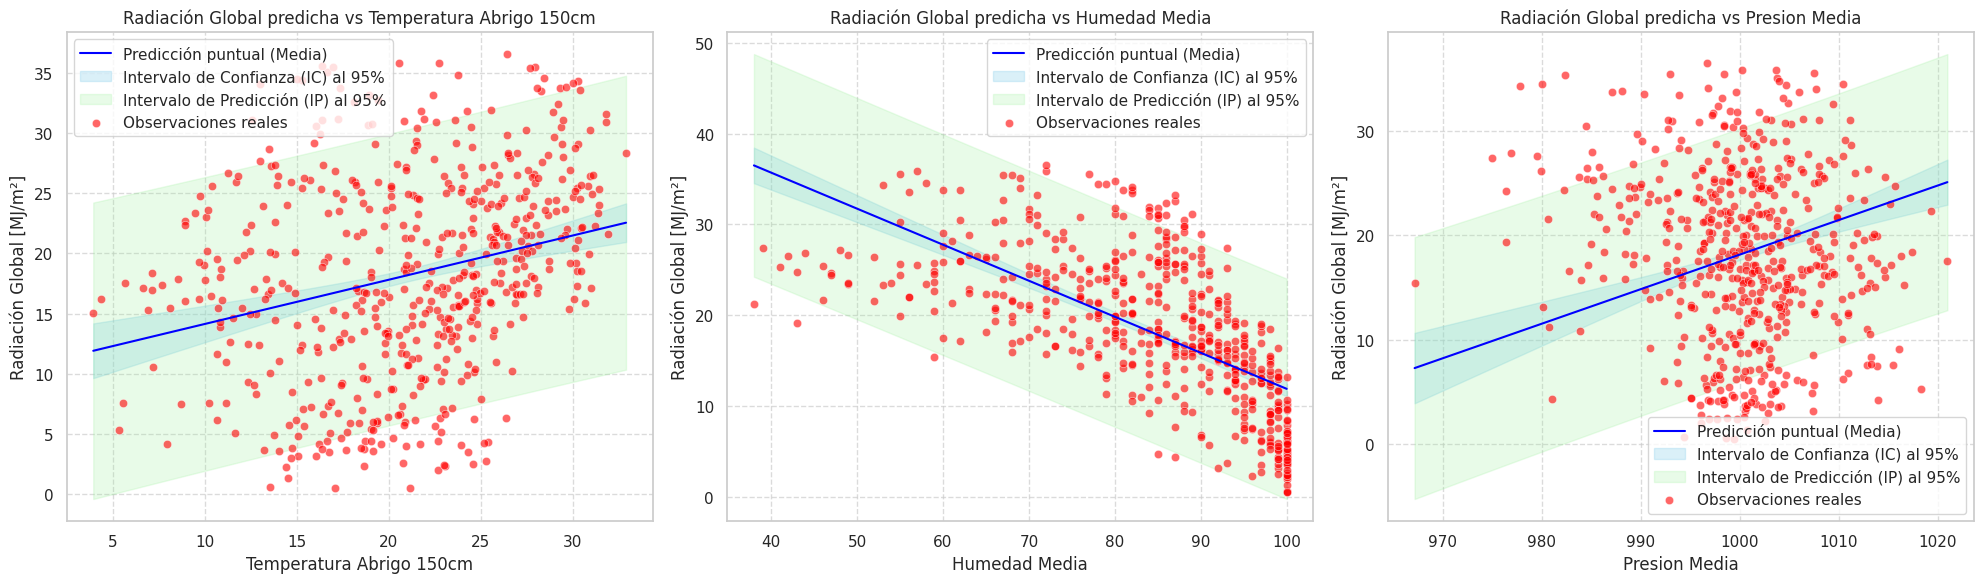

In [29]:
# *************************************************************
# GRÁFICOS DE IC (Intervalo de Confianza) E IP (Intervalo de Predicción) PARA CADA VARIABLE PREDICTORA
# *************************************************************
#En cada gráfico, se variará una de las variables explicativas a lo largo de su rango,
# mientras que las otras se mantendrán constantes en su valor medio.
# Obtener los valores medios de las variables para mantener constantes
mean_temp = df['Temperatura_Abrigo_150cm'].mean()
mean_hum = df['Humedad_Media'].mean()
mean_pres = df['Presion_Media'].mean()

# Variables predictoras del modelo múltiple
predictor_vars = ['Temperatura_Abrigo_150cm', 'Humedad_Media', 'Presion_Media']

# Crear una figura y un conjunto de subplots (1 fila, 3 columnas)
fig, axes = plt.subplots(1, len(predictor_vars), figsize=(20, 6))
axes = axes.flatten() # Aplanar para facilitar la indexación

for i, var_to_plot in enumerate(predictor_vars):
    # Crear un rango de valores para la variable que se va a graficar
    min_val = df[var_to_plot].min()
    max_val = df[var_to_plot].max()
    # Generar 100 puntos en el rango de la variable
    plot_range = np.linspace(min_val, max_val, 100)

    # Crear un DataFrame para las predicciones, asegurando la constante y el orden de columnas
    prediction_exog = pd.DataFrame(index=range(100))
    prediction_exog['const'] = 1.0  # Add the constant column first

    # Fill in the mean values for all predictor variables initially
    prediction_exog['Temperatura_Abrigo_150cm'] = mean_temp
    prediction_exog['Humedad_Media'] = mean_hum
    prediction_exog['Presion_Media'] = mean_pres

    # Replace the column for the variable being plotted with its range
    prediction_exog[var_to_plot] = plot_range

    # Ensure column order matches the model's exog (good practice)
    # Get the original column names from the model
    model_exog_names = modelo_mult.model.exog_names
    prediction_exog = prediction_exog[model_exog_names]

    # Obtener predicciones, IC y IP
    visual_preds = modelo_mult.get_prediction(prediction_exog)
    visual_preds_df = visual_preds.summary_frame(alpha=0.05)

    # Obtener el eje actual para el subplot
    ax = axes[i]

    # Predicción puntual
    sns.lineplot(x=plot_range, y=visual_preds_df['mean'], color='blue', label='Predicción puntual (Media)', ax=ax)

    # Intervalo de Confianza para la media (IC)
    ax.fill_between(
        plot_range, visual_preds_df['mean_ci_lower'], visual_preds_df['mean_ci_upper'],
        color='skyblue', alpha=0.3, label='Intervalo de Confianza (IC) al 95%'
    )

    # Intervalo de Predicción para una nueva observación (IP)
    ax.fill_between(
        plot_range, visual_preds_df['obs_ci_lower'], visual_preds_df['obs_ci_upper'],
        color='lightgreen', alpha=0.2, label='Intervalo de Predicción (IP) al 95%'
    )

    # Añadir los valores reales del dataset para la variable actual
    sns.scatterplot(x=df[var_to_plot], y=df['Radiacion_Global'], color='red', alpha=0.6, label='Observaciones reales', ax=ax)

    ax.set_title(f'Radiación Global predicha vs {var_to_plot.replace("_", " ")}')
    ax.set_xlabel(var_to_plot.replace("_", " "))
    ax.set_ylabel('Radiación Global [MJ/m²]')
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend()

plt.tight_layout() # Ajusta automáticamente el espaciado entre subplots
plt.show()

In [30]:
# ************************************
# COMPARACIÓN: MODELO SIMPLE vs MODELO MÚLTIPLE
# ************************************

print("*" * 60)
print("       COMPARACIÓN: REGRESIÓN SIMPLE vs MÚLTIPLE")
print("*" * 60)
print(f"  R² simple:              {modelo.rsquared:.4f}")       # R² del modelo con solo Temperatura
print(f"  R² múltiple:            {modelo_mult.rsquared:.4f}")  # R² del modelo con las 3 variables
print(f"  R² ajustado simple:     {modelo.rsquared_adj:.4f}")   # R² ajustado penaliza por más variables
print(f"  R² ajustado múltiple:   {modelo_mult.rsquared_adj:.4f}")
print(f"  AIC simple:             {modelo.aic:.2f}")             # AIC: menor es mejor (penaliza complejidad)
print(f"  AIC múltiple:           {modelo_mult.aic:.2f}")
print()
mejora = (modelo_mult.rsquared - modelo.rsquared) * 100         # Mejora en R² al agregar variables
print(f"  Aumento en R²: +{mejora:.2f}%")


************************************************************
       COMPARACIÓN: REGRESIÓN SIMPLE vs MÚLTIPLE
************************************************************
  R² simple:              0.0858
  R² múltiple:            0.4579
  R² ajustado simple:     0.0841
  R² ajustado múltiple:   0.4550
  AIC simple:             3876.94
  AIC múltiple:           3591.39

  Aumento en R²: +37.21%


---
######################################################################
# PARTE III — Estadística No Paramétrica
######################################################################

Los métodos no paramétricos no requieren asumir distribución Normal en los datos. Se utilizan como alternativa robusta cuando los supuestos paramétricos no se cumplen plenamente o como verificación adicional.

## III-A — Test no paramétrico: correlación de Spearman

Se repite el análisis de asociación entre Temperatura y Radiación usando el **coeficiente de correlación de Spearman (ρ)**.

> **¿Por qué Spearman?** A diferencia de Pearson, Spearman trabaja sobre los **rangos** de los datos (su posición ordenada) y no asume normalidad. Es robusto ante valores atípicos.

**Planteo del test:**

| | |
|---|---|
| **H₀:** | ρ = 0 → no existe asociación monótona entre las variables |
| **H₁:** | ρ ≠ 0 → existe asociación monótona estadísticamente significativa |
| **Tipo de test:** | Bilateral |
| **Nivel de significancia:** | α = 0.05 |

In [31]:
# ************************************
# TEST NO PARAMÉTRICO: CORRELACIÓN DE SPEARMAN
# H₀: ρ = 0   vs   H₁: ρ ≠ 0
# ************************************

# stats.spearmanr calcula el coeficiente de correlación de Spearman y su p-valor
# Trabaja sobre los rangos de los datos en lugar de los valores originales
rho, p_spearman = stats.spearmanr(xi, yi)

# Estadístico t aproximado para Spearman (misma fórmula que para Pearson sobre rangos)
T0_sp     = rho * np.sqrt(n - 2) / np.sqrt(1 - rho**2)    # Estadístico de prueba
t_crit_sp = stats.t.ppf(1 - 0.05/2, df=n - 2)             # Valor crítico bilateral con α = 0.05

print("=" * 60)
print("   TEST NO PARAMÉTRICO — Correlación de Spearman")
print("=" * 60)
print(f"  n (tamaño muestral):       {n}")
print(f"  ρ de Spearman:             {rho:.8f}")
print(f"  Estadístico T₀:            {T0_sp:.4f}")
print(f"  Valor crítico ±t(α/2,n-2): ±{t_crit_sp:.4f}")
print(f"  p-valor:                   {p_spearman:.4e}")
print()

# Decisión
if abs(T0_sp) > t_crit_sp:
    print(f"  |T₀| = {abs(T0_sp):.4f} > t_crit = {t_crit_sp:.4f}  →  Se RECHAZA H₀")
else:
    print(f"  |T₀| = {abs(T0_sp):.4f} ≤ t_crit = {t_crit_sp:.4f}  →  No se rechaza H₀")
print()
if p_spearman < 0.05:
    print(f"  DECISIÓN: Se RECHAZA H₀ (p-valor = {p_spearman:.4e} < α = 0.05)")
    print("  CONCLUSIÓN: Existe una asociación monótona positiva y")
    print(f"  estadísticamente significativa (ρ = {rho:.4f}).")
else:
    print("  DECISIÓN: No se rechaza H₀.")

print()
print("=" * 60)
print("   COMPARACIÓN: PARAMÉTRICO vs NO PARAMÉTRICO")
print("=" * 60)
print(f"  Pearson  r = {pearson_r:.6f}  |  p-valor = {p_pearson:.4e}")   # Resultado de II-D
print(f"  Spearman ρ = {rho:.6f}  |  p-valor = {p_spearman:.4e}")
print()
print("  Ambos métodos conducen a la misma conclusión.")
print("  La similitud entre r y ρ indica que la relación")
print("  es aproximadamente lineal y sin influencia")
print("  fuerte de valores atípicos.")

   TEST NO PARAMÉTRICO — Correlación de Spearman
  n (tamaño muestral):       554
  ρ de Spearman:             0.31970769
  Estadístico T₀:            7.9275
  Valor crítico ±t(α/2,n-2): ±1.9643
  p-valor:                   1.2451e-14

  |T₀| = 7.9275 > t_crit = 1.9643  →  Se RECHAZA H₀

  DECISIÓN: Se RECHAZA H₀ (p-valor = 1.2451e-14 < α = 0.05)
  CONCLUSIÓN: Existe una asociación monótona positiva y
  estadísticamente significativa (ρ = 0.3197).

   COMPARACIÓN: PARAMÉTRICO vs NO PARAMÉTRICO
  Pearson  r = 0.292861  |  p-valor = 2.0314e-12
  Spearman ρ = 0.319708  |  p-valor = 1.2451e-14

  Ambos métodos conducen a la misma conclusión.
  La similitud entre r y ρ indica que la relación
  es aproximadamente lineal y sin influencia
  fuerte de valores atípicos.


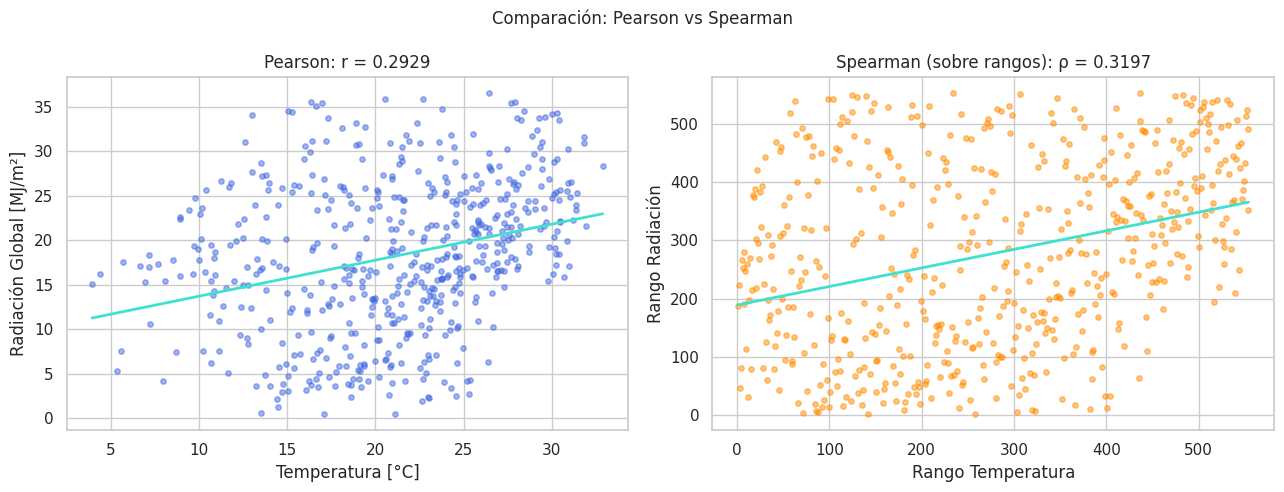

In [32]:
# ************************************
# VISUALIZACIÓN COMPARATIVA
# Pearson (valores originales) vs Spearman (rangos)
# ************************************

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel izquierdo: Pearson sobre valores originales ---
axes[0].scatter(xi, yi, s=15, alpha=0.5, color='royalblue')    # Puntos originales
m_p, b_p = np.polyfit(xi, yi, 1)                               # Línea de tendencia sobre datos originales
x_r = np.linspace(xi.min(), xi.max(), 100)                     # Rango de X para graficar la recta
axes[0].plot(x_r, m_p * x_r + b_p, color='turquoise', linewidth=2)
axes[0].set_title(f'Pearson: r = {pearson_r:.4f}')
axes[0].set_xlabel('Temperatura [°C]')
axes[0].set_ylabel('Radiación Global [MJ/m²]')

# --- Panel derecho: Spearman sobre rangos ---
rangos_x = stats.rankdata(xi)                                   # Reemplaza cada valor por su posición ordenada
rangos_y = stats.rankdata(yi)                                   # Idem para Y
axes[1].scatter(rangos_x, rangos_y, s=15, alpha=0.5, color='darkorange')
m_s, b_s = np.polyfit(rangos_x, rangos_y, 1)                   # Línea de tendencia sobre rangos
x_rs = np.linspace(rangos_x.min(), rangos_x.max(), 100)
axes[1].plot(x_rs, m_s * x_rs + b_s, color='turquoise', linewidth=2)
axes[1].set_title(f'Spearman (sobre rangos): ρ = {rho:.4f}')
axes[1].set_xlabel('Rango Temperatura')
axes[1].set_ylabel('Rango Radiación')

plt.suptitle('Comparación: Pearson vs Spearman', fontsize=12)
plt.tight_layout()
plt.show()